# Assignment 1: Steam Recommendation System

**Dataset:** Steam Review and Bundle Dataset (HuggingFace)

| File | Description |
|---|---|
| `australian_user_reviews.json.gz` | User reviews with binary `recommend` signal |
| `australian_users_items.json.gz` | Games owned by users + playtime (minutes) |
| `bundle_data.json.gz` | Steam bundles and their item contents |
| `steam_games.json.gz` | Game metadata: genres, tags, price, publisher, release date |
| `steam_reviews.json.gz` | Aggregated reviews with hours played |

---

## Table of Contents

1. [Setup & Data Download](#1-setup--data-download)
2. [Data Loading](#2-data-loading)
3. [Dataset Overview](#3-dataset-overview)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
   - [A. Dataset Overview](#a-dataset-overview)
   - [B. Data Quality Assessment](#b-data-quality-assessment)
   - [C. Data Preprocessing](#c-data-preprocessing)
   - [D. Univariate Analysis](#d-univariate-analysis)
   - [E. Bivariate Analysis](#e-bivariate-analysis)
   - [F. Multivariate Analysis](#f-multivariate-analysis)
   - [G. Outlier & Anomaly Analysis](#g-outlier--anomaly-analysis)
   - [H. Target Analysis](#h-target-analysis)
   - [I. Feature Usefulness Review](#i-feature-usefulness-review)
   - [J. Business / Domain Insight Summary](#j-business--domain-insight-summary)

---
## 1. Setup & Data Download

In [7]:
import os

DATA_DIR = "./steam-review-and-bundle-dataset"

if not os.path.exists(DATA_DIR):
    !git clone https://huggingface.co/datasets/recommender-system/steam-review-and-bundle-dataset
else:
    !cd {DATA_DIR} && git pull

Already up to date.


In [8]:
import sys
sys.path.insert(0, "..")

import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pathlib import Path
from scipy import stats as scipy_stats
from sklearn.preprocessing import StandardScaler

from project2.dataset import load_all_datasets, parse_price
from project2.plots import (
    set_style,
    plot_recommend_distribution,
    plot_reviews_per_user, plot_items_per_user,
    plot_reviews_per_item, plot_top_reviewed_games, plot_top_played_games,
    plot_playtime_distribution, plot_playtime_vs_recommend,
    plot_genre_distribution, plot_top_tags, plot_price_distribution,
    plot_release_year_distribution, plot_early_access_distribution,
    plot_hours_distribution, plot_reviews_over_time,
    plot_sparsity,
)

set_style()
DATA_PATH = Path(DATA_DIR)
print("Imports OK")

Imports OK


 ---
## 2. Data Loading

In [9]:
df_reviews, df_items, df_games, df_bundles, df_steam_rev = load_all_datasets(DATA_PATH)
print("All datasets loaded.")

2026-04-15 17:58:28.902 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: australian_user_reviews.parquet
2026-04-15 17:58:28.995 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: australian_users_items.parquet
2026-04-15 17:58:29.341 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: steam_games.parquet
2026-04-15 17:58:29.459 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: bundle_data.parquet
2026-04-15 17:58:29.466 | INFO     | project2.dataset:_load_or_cache:184 - Loading from cache: steam_reviews.parquet
2026-04-15 17:58:36.543 | INFO     | project2.dataset:load_all_datasets:311 - All datasets loaded.
All datasets loaded.


---
## 3. Dataset Overview

Before diving into analysis, we get a high-level summary of every dataset: shape, unique users/items, and missing values.

In [10]:
summary = pd.DataFrame([
    {"Dataset": "df_reviews",  "Rows": len(df_reviews),  "Columns": len(df_reviews.columns),  "Unique Users": df_reviews["user_id"].nunique(),   "Unique Items": df_reviews["item_id"].nunique()},
    {"Dataset": "df_items",    "Rows": len(df_items),    "Columns": len(df_items.columns),    "Unique Users": df_items["user_id"].nunique(),     "Unique Items": df_items["item_id"].nunique()},
    {"Dataset": "df_games",    "Rows": len(df_games),    "Columns": len(df_games.columns),    "Unique Users": None,                              "Unique Items": df_games["id"].nunique()},
    {"Dataset": "df_bundles",  "Rows": len(df_bundles),  "Columns": len(df_bundles.columns),  "Unique Users": None,                              "Unique Items": None},
    {"Dataset": "df_steam_rev","Rows": len(df_steam_rev),"Columns": len(df_steam_rev.columns),"Unique Users": df_steam_rev["username"].nunique(),"Unique Items": df_steam_rev["product_id"].nunique()},
])
display(summary)

,Dataset,Rows,Columns,Unique Users,Unique Items
0,df_reviews,59305,7,25458.0,3682.0
1,df_items,5153209,5,70912.0,10978.0
2,df_games,32135,17,NaN,32132.0
3,df_bundles,615,7,NaN,NaN
4,df_steam_rev,7793069,12,2567538.0,15474.0


In [11]:
for name, df in [
    ("df_reviews",  df_reviews),
    ("df_items",    df_items),
    ("df_games",    df_games),
    ("df_bundles",  df_bundles),
    ("df_steam_rev",df_steam_rev),
]:
    print(f"=== {name} columns ===")
    print(df.dtypes)
    print()

=== df_reviews columns ===
user_id       str
item_id       str
recommend    bool
review        str
posted        str
helpful       str
funny         str
dtype: object

=== df_items columns ===
user_id               str
item_id               str
item_name             str
playtime_forever    int64
playtime_2weeks     int64
dtype: object

=== df_games columns ===
publisher             str
genres             object
app_name              str
title                 str
url                   str
release_date          str
tags               object
discount_price    float64
reviews_url           str
specs              object
price                 str
early_access         bool
id                    str
developer             str
sentiment             str
metascore             str
price_numeric     float64
dtype: object

=== df_bundles columns ===
bundle_final_price    str
bundle_url            str
bundle_price          str
bundle_name           str
bundle_id             str
items                 s

---
## 4. Exploratory Data Analysis

Single structured EDA covering all five Steam datasets. Target variable: `recommend` (boolean, `df_reviews`).

| Sub-section | Topic |
|-------------|---|
| A           | Dataset Overview — shape, dtypes, granularity, duplicates |
| C           | Preprocessing — cleaning steps + summary table |
| D           | Univariate — distributions per column type |
| E           | Bivariate — pairwise relationships & target analysis |
| F           | Multivariate — correlations, VIF, sparsity |
| G           | Outlier & Anomaly — detection & treatment recommendations |
| H           | Target Analysis — class balance, stratification |
| I           | Feature Usefulness — ranking, leakage, derived features |

### A. Dataset Overview

In [12]:
key_pairs = [
    ("df_reviews",   df_reviews,   ["user_id", "item_id"]),
    ("df_items",     df_items,     ["user_id", "item_id"]),
    ("df_games",     df_games,     ["id"]),
    ("df_steam_rev", df_steam_rev, ["username", "product_id"]),
]
for name, df, keys in key_pairs:
    n_dups = df.duplicated(subset=keys).sum()
    print(f"  {name:<16} keys={keys}  dup_key_rows={n_dups:,}")
print(f"  {'df_bundles':<16} fully-dup rows={df_bundles.duplicated().sum():,}")

# Column type taxonomy
def classify_col(s, df):
    if s.empty: return "empty"
    if pd.api.types.is_bool_dtype(s): return "boolean"
    if pd.api.types.is_datetime64_any_dtype(s): return "datetime"
    if hasattr(s, 'apply') and s.apply(lambda x: isinstance(x, (list, np.ndarray))).sum() > len(s) * 0.5:
        return "list/array"
    if pd.api.types.is_numeric_dtype(s):
        return "numeric"
    if s.nunique() == 1: return "constant"
    if s.nunique() <= 2: return "binary"
    if s.nunique() <= 20: return "low-card categorical"
    if s.nunique() / max(len(df), 1) > 0.8: return "high-card / ID"
    return "categorical / text"

print()
for name, df in DATASETS.items():
    print(f"  {name}")
    print(f"  {'col':<26} {'kind':<24} {'nuniq':>7}  {'null%':>6}")
    print(f"  {'-'*66}")
    for col in df.columns:
        s = df[col].dropna()
        kind = classify_col(s, df)
        if kind == "list/array":
            nuniq_str = "N/A"
        else:
            nuniq_str = f"{df[col].nunique():>7,}"
        print(f"  {col:<26} {kind:<24} {nuniq_str:>7}  {df[col].isnull().mean()*100:>5.1f}%")
    print()

  df_reviews       keys=['user_id', 'item_id']  dup_key_rows=874
  df_items         keys=['user_id', 'item_id']  dup_key_rows=59,127
  df_games         keys=['id']  dup_key_rows=2
  df_steam_rev     keys=['username', 'product_id']  dup_key_rows=903,341
  df_bundles       fully-dup rows=0

  df_reviews
  col                        kind                       nuniq   null%
  ------------------------------------------------------------------
  user_id                    categorical / text        25,458    0.0%
  item_id                    categorical / text         3,682    0.0%
  recommend                  boolean                        2    0.0%
  review                     high-card / ID            55,313    0.0%
  posted                     categorical / text         1,906    0.0%
  helpful                    categorical / text         1,344    0.0%
  funny                      categorical / text           186    0.0%

  df_items
  col                        kind                       

### C. Data Preprocessing

In [13]:
# ── C. Data Preprocessing ──────────────────────────────────────────────────────

# Work on copies — never modify raw frames
df_rev = df_reviews.copy()
df_itm = df_items.copy()
df_gm  = df_games.copy()
df_bun = df_bundles.copy()
df_sr  = df_steam_rev.copy()

# C1. Trim string columns
for col in ["user_id", "item_id", "review", "posted", "helpful"]:
    df_rev[col] = df_rev[col].astype(str).str.strip()
for col in ["user_id", "item_id", "item_name"]:
    df_itm[col] = df_itm[col].astype(str).str.strip()
for col in ["username", "product_id"]:
    if col in df_sr.columns:
        df_sr[col] = df_sr[col].astype(str).str.strip()

# C2. Parse posted date ("Posted November 12, 2014.")
def parse_posted(s):
    if not isinstance(s, str) or s.strip() in ("", "nan"):
        return pd.NaT
    s = re.sub(r"^Posted\s+", "", s.strip().rstrip("."))
    return pd.to_datetime(s, format="%B %d, %Y", errors="coerce")

df_rev["posted_date"]  = df_rev["posted"].apply(parse_posted)
df_rev["posted_year"]  = df_rev["posted_date"].dt.year
df_rev["posted_month"] = df_rev["posted_date"].dt.month
ok = df_rev["posted_date"].notna().sum()
print(f"C2. posted_date parsed: {ok:,}/{len(df_rev):,}  ({ok/len(df_rev)*100:.1f}%)")

# C3. Extract helpful vote counts from strings
def parse_votes(s):
    if not isinstance(s, str): return 0
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else 0

df_rev["helpful_votes"] = df_rev["helpful"].apply(parse_votes)
print(f"C3. helpful_votes max: {df_rev['helpful_votes'].max():,}")

# C4. Review text length + has_text flag
df_rev["review_len"] = df_rev["review"].str.len().fillna(0).astype(int)
df_rev["has_text"]   = df_rev["review"].str.strip().str.len() > 0

# C5. Playtime: log1p transform + cap at 99.9th pct
p999 = df_itm["playtime_forever"].quantile(0.999)
df_itm["playtime_forever_capped"] = df_itm["playtime_forever"].clip(upper=p999)
df_itm["playtime_log1p"]          = np.log1p(df_itm["playtime_forever"])
print(f"C5. playtime_forever 99.9th pct = {p999:,.0f} min ({p999/60:,.0f} h)")

# C6. Games: release year, is_free, list-length features
df_gm["release_date_parsed"] = pd.to_datetime(df_gm["release_date"], errors="coerce")
df_gm["release_year"] = df_gm["release_date_parsed"].dt.year
df_gm["is_free"]      = df_gm["price_numeric"] == 0
df_gm["n_genres"]     = df_gm["genres"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_gm["n_tags"]       = df_gm["tags"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_gm["n_specs"]      = df_gm["specs"].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_gm["early_access"] = df_gm["early_access"].fillna(False)

# C7. steam_reviews: numeric hours + products
df_sr["hours"]    = pd.to_numeric(df_sr["hours"], errors="coerce")
df_sr["products"] = pd.to_numeric(df_sr["products"], errors="coerce")

print("Preprocessing complete.")

# Preprocessing summary table
prep_rows = [
    ("df_reviews",  "recommend",        "bool",  "bool",     0.0,                                          "target column",              "use as-is (binary target)"),
    ("df_reviews",  "posted",           "str",   "datetime", round(df_reviews["posted"].isnull().mean()*100,1), "free-text date",         "-> posted_date, posted_year, posted_month"),
    ("df_reviews",  "helpful",          "str",   "int",      0.0,                                          "vote count in string",       "-> helpful_votes (int)"),
    ("df_reviews",  "review",           "str",   "str",      0.0,                                          "blank entries present",      "-> review_len, has_text flag"),
    ("df_items",    "playtime_forever", "int",   "int",      0.0,                                          "heavy right skew",           "log1p + cap at 99.9th pct"),
    ("df_games",    "price",            "str",   "float",    round(df_games["price"].isnull().mean()*100,1), "mixed str/float",          "-> price_numeric; is_free flag"),
    ("df_games",    "genres",           "list",  "list",     round(df_games["genres"].isnull().mean()*100,1), "list column",             "-> n_genres count"),
    ("df_games",    "release_date",     "str",   "datetime", round(df_games["release_date"].isnull().mean()*100,1), "mixed formats",    "-> release_year"),
    ("df_games",    "early_access",     "bool",  "bool",     round(df_games["early_access"].isnull().mean()*100,1), "NaNs present",   "fill NaN -> False"),
    ("df_steam_rev","hours",            "mixed", "float",    round(df_sr["hours"].isnull().mean()*100,1),  "stored as str/num",          "coerce to float"),
]
prep_df = pd.DataFrame(prep_rows, columns=[
    "dataset", "column", "orig_dtype", "clean_dtype", "null%", "issues", "treatment"
])
display(prep_df)

C2. posted_date parsed: 49,186/59,305  (82.9%)
C3. helpful_votes max: 981
C5. playtime_forever 99.9th pct = 74,706 min (1,245 h)
Preprocessing complete.


,dataset,column,orig_dtype,clean_dtype,null%,issues,treatment
0,df_reviews,recommend,bool,bool,0.0,target column,use as-is (binary target)
1,df_reviews,posted,str,datetime,0.0,free-text date,"-> posted_date, posted_year, posted_month"
2,df_reviews,helpful,str,int,0.0,vote count in string,-> helpful_votes (int)
3,df_reviews,review,str,str,0.0,blank entries present,"-> review_len, has_text flag"
4,df_items,playtime_forever,int,int,0.0,heavy right skew,log1p + cap at 99.9th pct
5,df_games,price,str,float,4.3,mixed str/float,-> price_numeric; is_free flag
6,df_games,genres,list,list,10.2,list column,-> n_genres count
7,df_games,release_date,str,datetime,6.4,mixed formats,-> release_year
8,df_games,early_access,bool,bool,0.0,NaNs present,fill NaN -> False
9,df_steam_rev,hours,mixed,float,0.3,stored as str/num,coerce to float


### D. Univariate Analysis

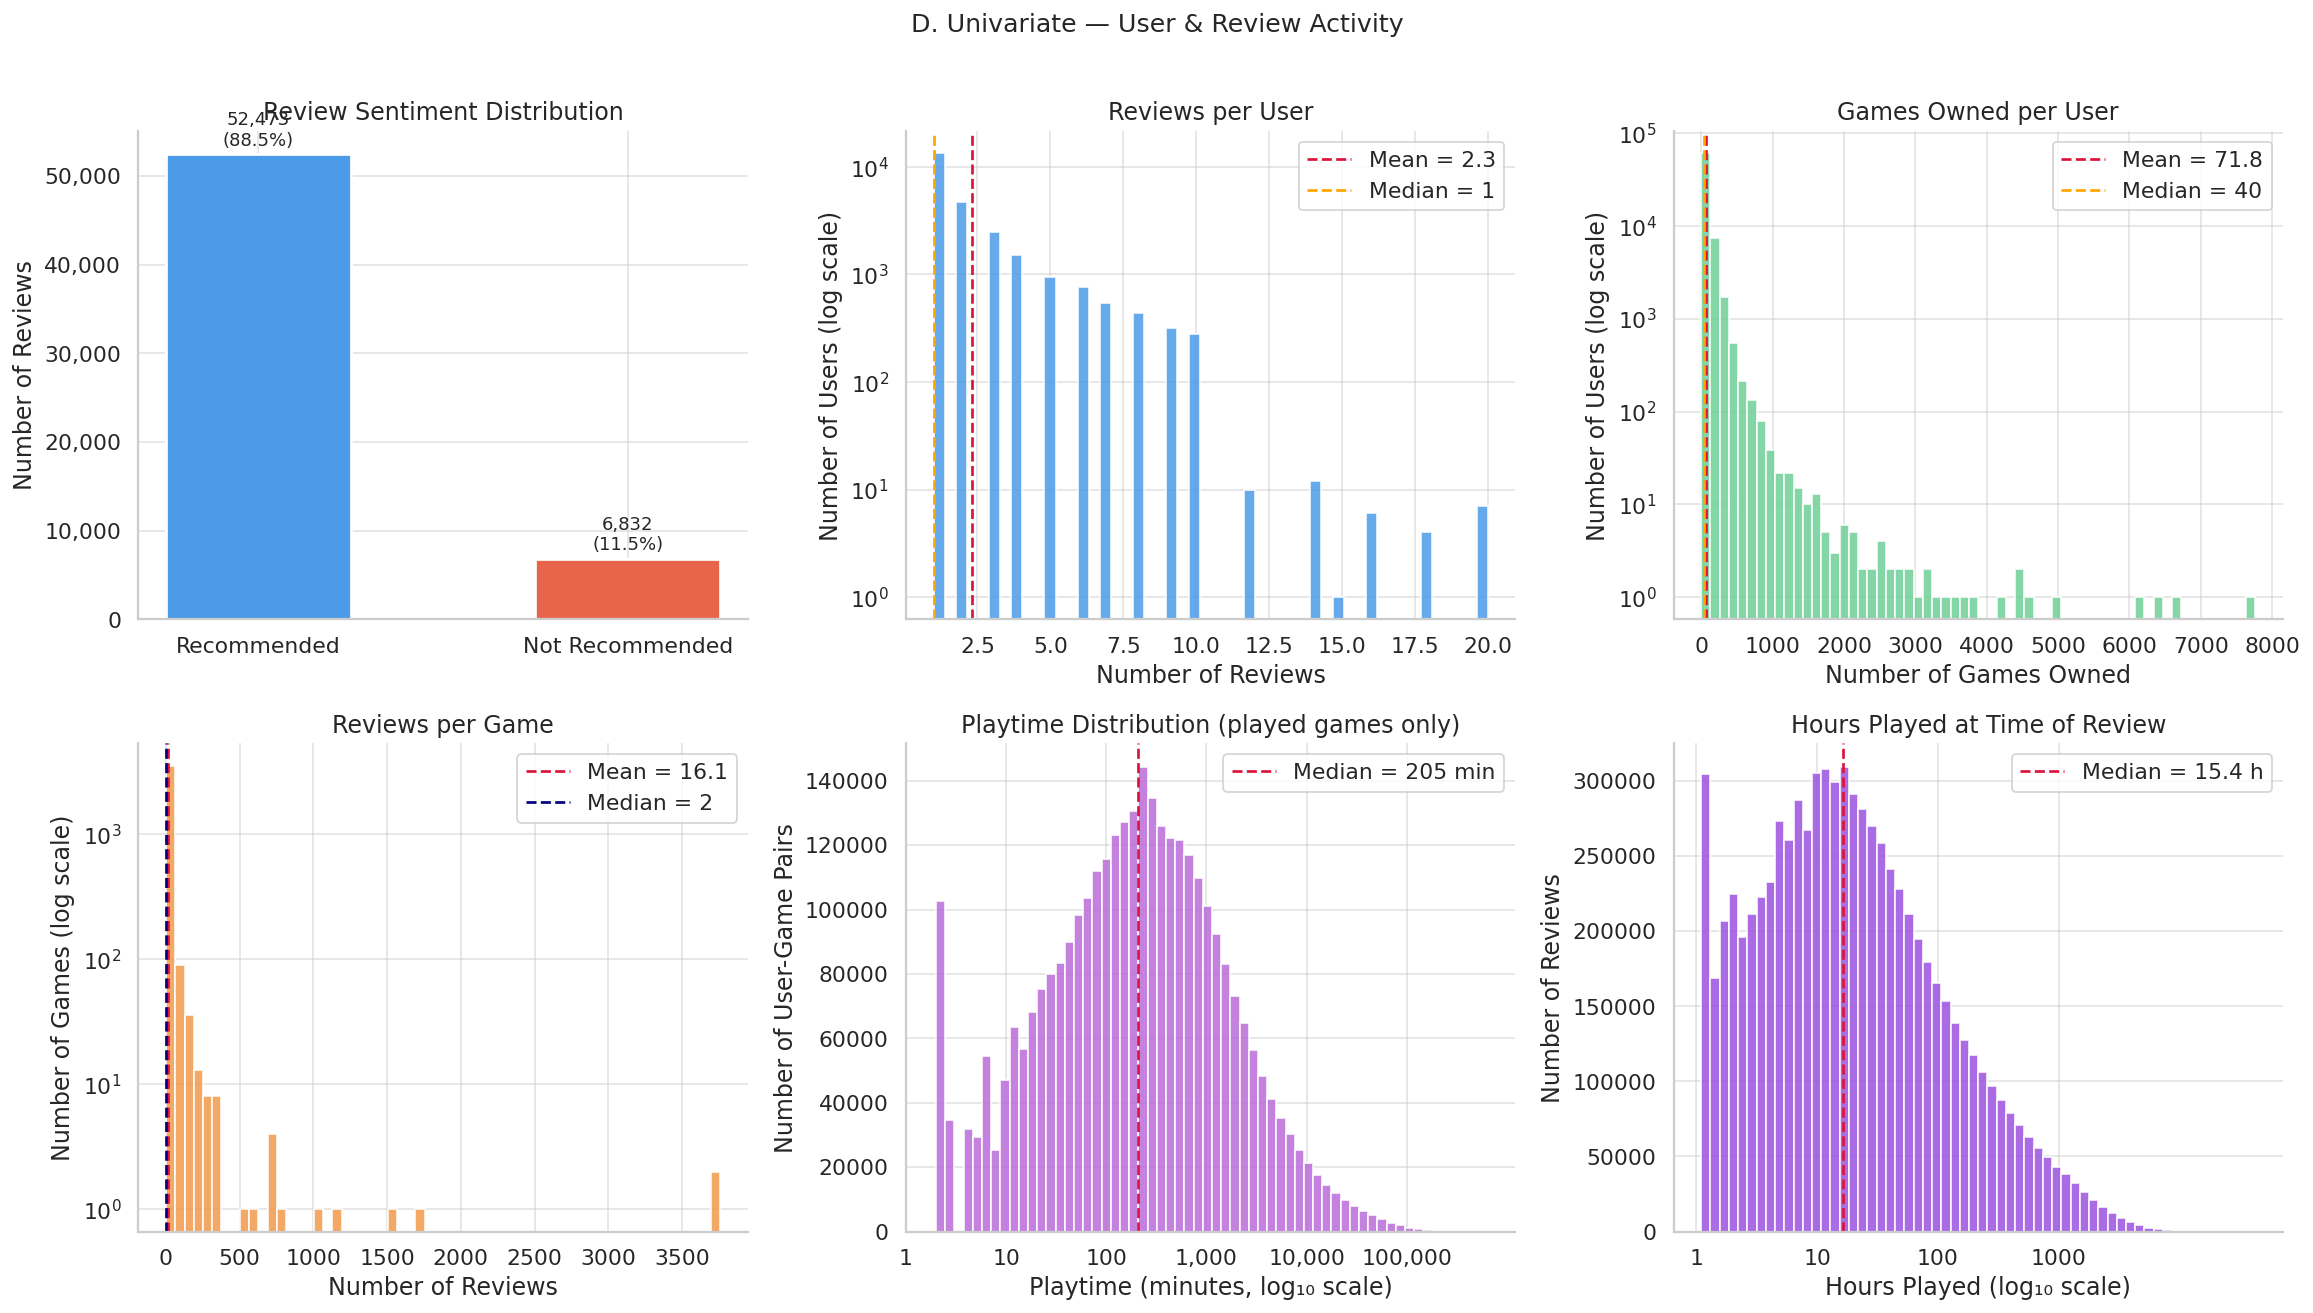

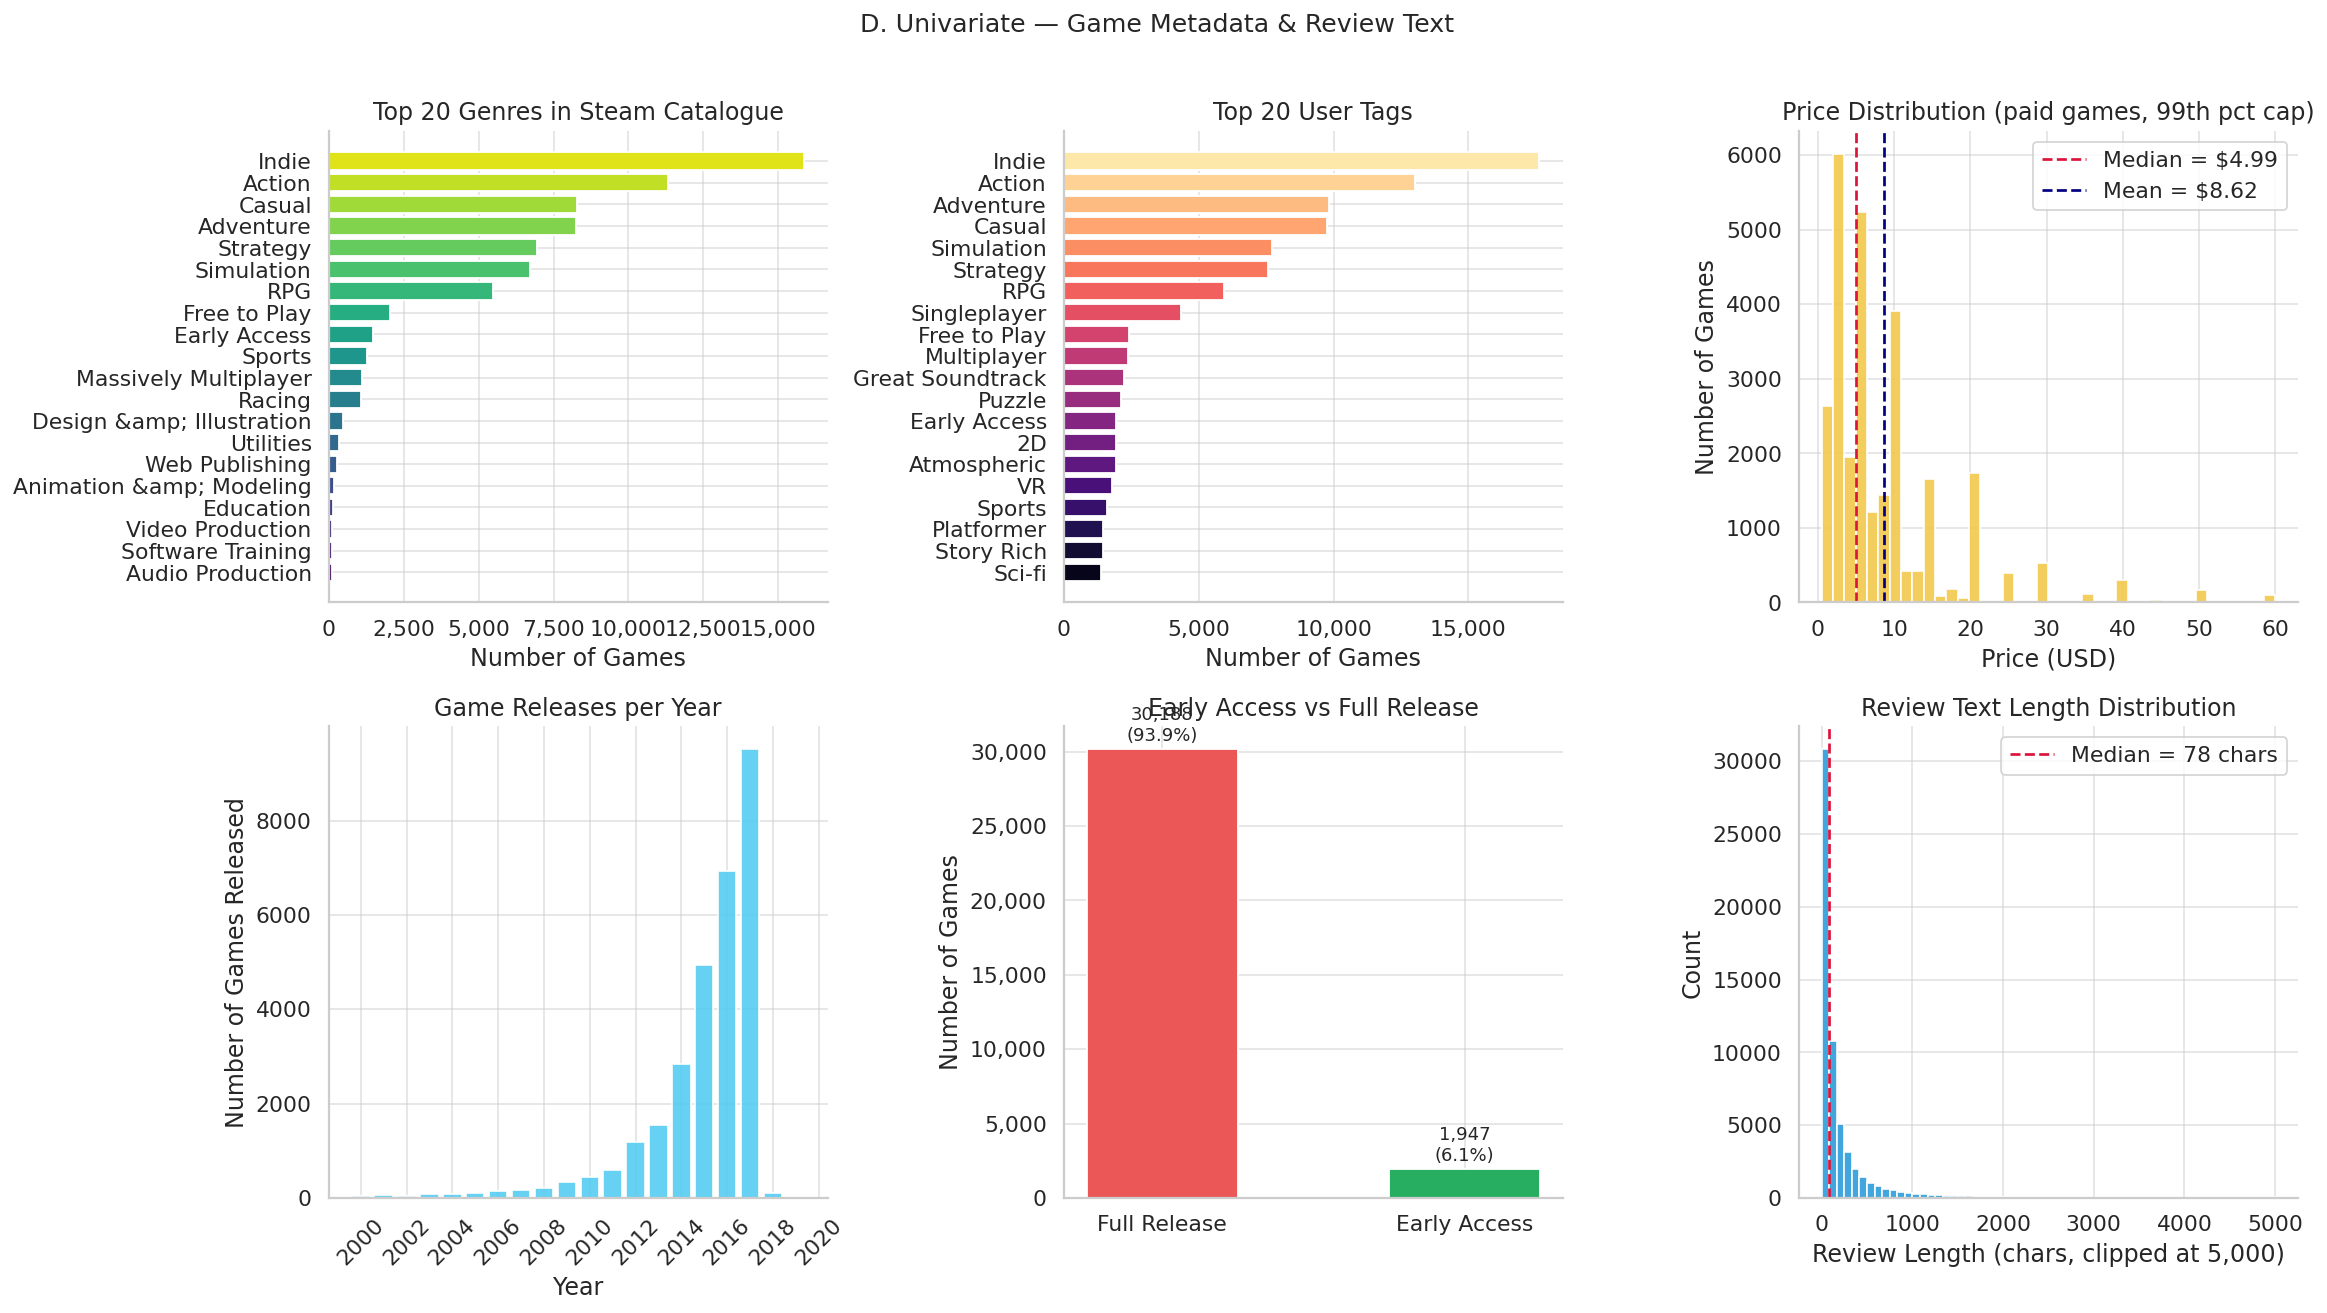

=== Numeric Summary — df_items ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
playtime_forever,5153209.0,991.5,5418.2,0.0,0.0,0.0,0.0,34.0,355.0,3675.0,17947.0,642773.0
playtime_2weeks,5153209.0,9.1,140.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,148.0,19967.0



=== Numeric Summary — df_games ===


,count,mean,std,min,1%,25%,50%,75%,99%,max
price_numeric,30735.0,8.87,15.91,0.0,0.0,2.99,4.99,9.99,54.99,995.0
n_genres,32135.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0
n_tags,32135.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0
n_specs,32135.0,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.0
release_year,29783.0,2014.76,3.51,1970.0,1998.0,2014.00,2016.00,2017.00,2017.00,2021.0



=== Skewness ===


,column,skewness,note
0,df_items.playtime_forever,20.48,log transform recommended
1,df_items.playtime_2weeks,38.43,log transform recommended
2,df_games.price_numeric,20.61,log transform recommended
3,df_games.n_genres,NaN,ok
4,df_games.n_tags,NaN,ok


In [14]:
# ── D. Univariate Analysis ─────────────────────────────────────────────────────

# D1: User & review activity
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_recommend_distribution(df_rev, ax=axes[0, 0])
plot_reviews_per_user(df_rev, ax=axes[0, 1])
plot_items_per_user(df_itm, ax=axes[0, 2])
plot_reviews_per_item(df_rev, ax=axes[1, 0])
plot_playtime_distribution(df_itm, ax=axes[1, 1])
plot_hours_distribution(df_sr, ax=axes[1, 2])
plt.suptitle("D. Univariate — User & Review Activity", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# D2: Game metadata
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_genre_distribution(df_gm, ax=axes[0, 0])
plot_top_tags(df_gm, ax=axes[0, 1])
plot_price_distribution(df_gm, ax=axes[0, 2])
plot_release_year_distribution(df_gm, ax=axes[1, 0])
plot_early_access_distribution(df_gm, ax=axes[1, 1])

ax = axes[1, 2]
ax.hist(df_rev["review_len"].clip(upper=5000), bins=60,
        color="#2D9CDB", edgecolor="white", alpha=0.9)
med_len = df_rev["review_len"].median()
ax.axvline(med_len, color="crimson", linestyle="--", label=f"Median = {med_len:.0f} chars")
ax.set_xlabel("Review Length (chars, clipped at 5,000)")
ax.set_ylabel("Count")
ax.set_title("Review Text Length Distribution")
ax.legend()
plt.suptitle("D. Univariate — Game Metadata & Review Text", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# D3: Numeric summary stats
print("=== Numeric Summary — df_items ===")
display(df_itm[["playtime_forever", "playtime_2weeks"]].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.round(1))

print("\n=== Numeric Summary — df_games ===")
display(df_gm[["price_numeric", "n_genres", "n_tags", "n_specs", "release_year"]].describe(
    percentiles=[.01, .25, .5, .75, .99]).T.round(2))

print("\n=== Skewness ===")
skew_rows = []
for col in ["playtime_forever", "playtime_2weeks"]:
    sk = scipy_stats.skew(df_itm[col].dropna())
    skew_rows.append({"column": f"df_items.{col}", "skewness": round(sk, 2),
                       "note": "log transform recommended" if abs(sk) > 2 else "ok"})
for col in ["price_numeric", "n_genres", "n_tags"]:
    sk = scipy_stats.skew(df_gm[col].dropna())
    skew_rows.append({"column": f"df_games.{col}", "skewness": round(sk, 2),
                       "note": "log transform recommended" if abs(sk) > 2 else "ok"})
display(pd.DataFrame(skew_rows))

### E. Bivariate Analysis

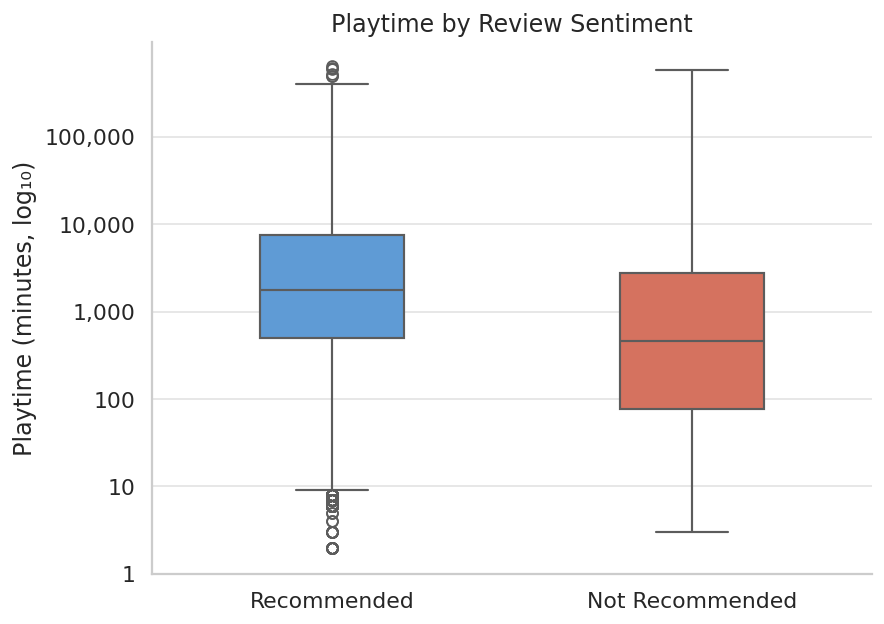

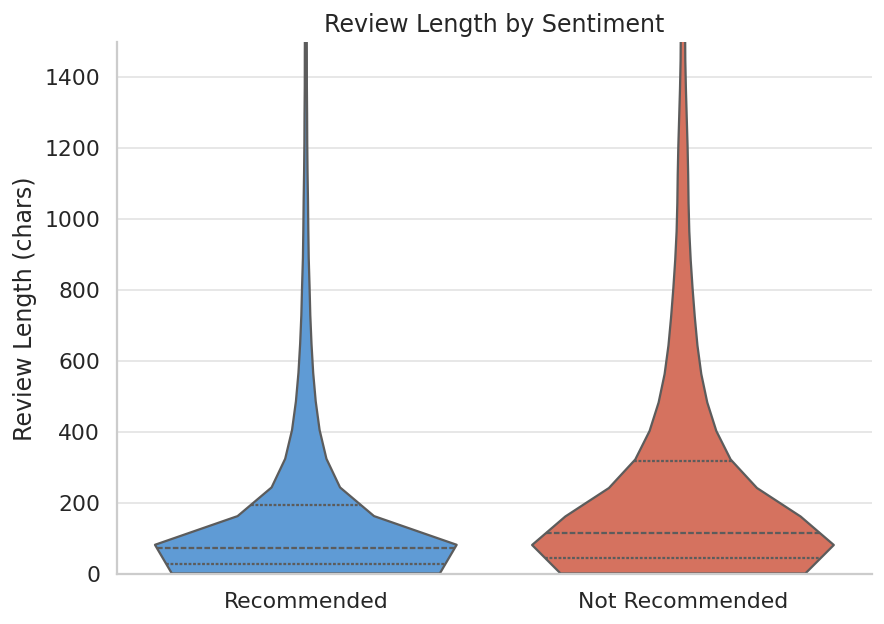

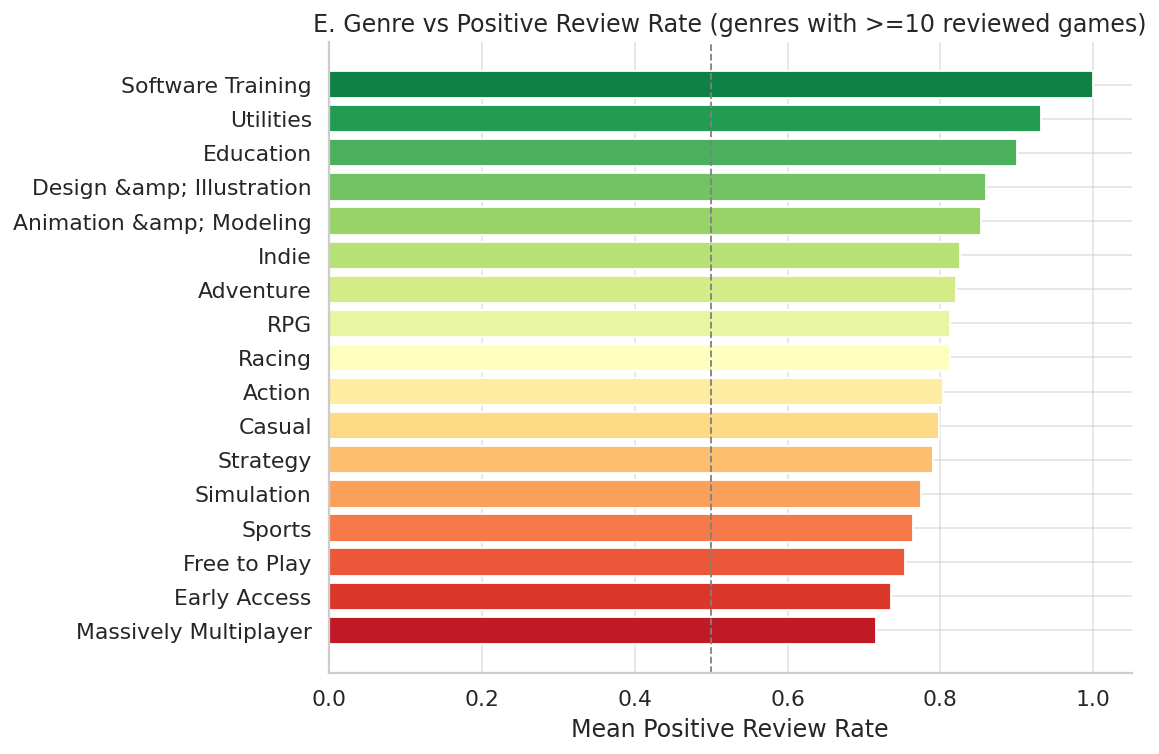

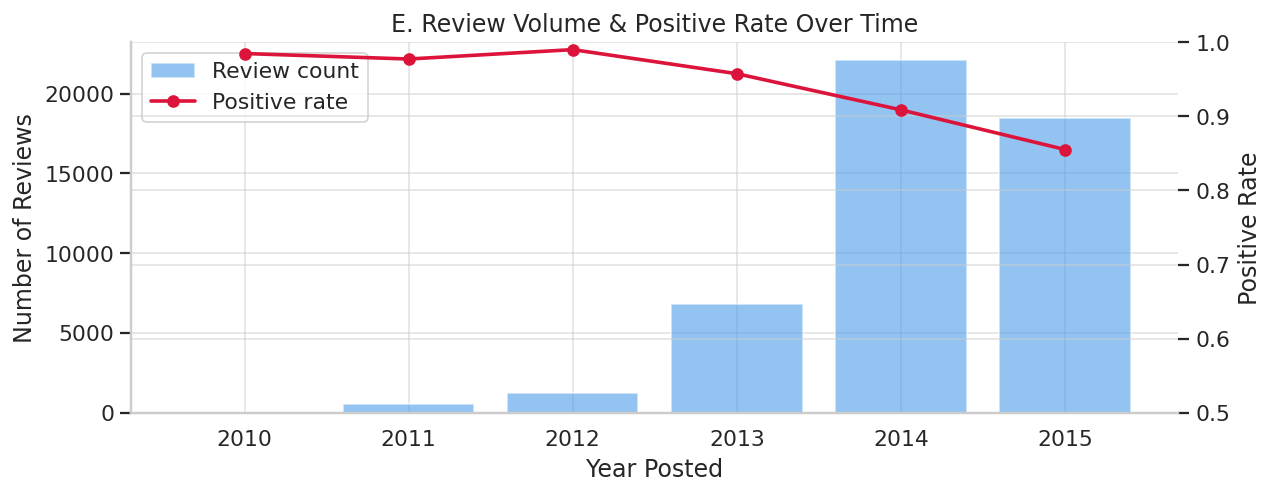

In [15]:
# ── E. Bivariate Analysis ──────────────────────────────────────────────────────

# E1: Playtime vs recommend
fig, ax = plt.subplots(figsize=(7, 5))
plot_playtime_vs_recommend(df_rev, df_itm, ax=ax)
plt.tight_layout()
plt.show()

play_merged = df_rev.merge(
    df_itm[["user_id", "item_id", "playtime_forever", "playtime_2weeks"]],
    on=["user_id", "item_id"], how="left"
)
play_merged["log_playtime"] = np.log1p(play_merged["playtime_forever"].fillna(0))
play_merged["sentiment"]    = play_merged["recommend"].map({True: "Recommended", False: "Not Recommended"})

# E2: Review length vs recommend
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(
    data=play_merged[play_merged["review_len"] > 0],
    x="sentiment", y="review_len",
    palette={"Recommended": "#4C9BE8", "Not Recommended": "#E8654C"},
    ax=ax, cut=0, inner="quartile"
)
ax.set_ylim(0, play_merged["review_len"].quantile(0.98))
ax.set_title("Review Length by Sentiment")
ax.set_xlabel("")
ax.set_ylabel("Review Length (chars)")
plt.tight_layout()
plt.show()

# E3: Genre vs positive review rate
genres_exp = df_gm[["id", "genres"]].explode("genres").dropna(subset=["genres"])
genres_exp = genres_exp.rename(columns={"id": "item_id"})
rec_rate   = df_rev.groupby("item_id")["recommend"].mean().reset_index(name="pos_rate")
genre_rec  = genres_exp.merge(rec_rate, on="item_id", how="inner")
genre_agg  = (
    genre_rec.groupby("genres")
    .agg(mean_pos_rate=("pos_rate", "mean"), n_games=("item_id", "nunique"))
    .reset_index()
)
genre_agg = genre_agg[genre_agg["n_games"] >= 10].sort_values("mean_pos_rate")

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette("RdYlGn", len(genre_agg))
ax.barh(genre_agg["genres"], genre_agg["mean_pos_rate"], color=colors, edgecolor="white")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Mean Positive Review Rate")
ax.set_title("E. Genre vs Positive Review Rate (genres with >=10 reviewed games)")
plt.tight_layout()
plt.show()

# E4: Review volume + positive rate over time
if df_rev["posted_year"].notna().sum() > 1000:
    time_agg = (
        df_rev.groupby("posted_year")
        .agg(n_reviews=("recommend", "count"), pos_rate=("recommend", "mean"))
        .reset_index()
        .dropna()
    )
    time_agg = time_agg[(time_agg["posted_year"] >= 2010) & (time_agg["posted_year"] <= 2018)]
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()
    ax1.bar(time_agg["posted_year"], time_agg["n_reviews"], color="#4C9BE8", alpha=0.6, label="Review count")
    ax2.plot(time_agg["posted_year"], time_agg["pos_rate"], color="crimson", marker="o", linewidth=2, label="Positive rate")
    ax1.set_xlabel("Year Posted")
    ax1.set_ylabel("Number of Reviews")
    ax2.set_ylabel("Positive Rate")
    ax2.set_ylim(0.5, 1.0)
    ax1.set_title("E. Review Volume & Positive Rate Over Time")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough parsed dates for temporal plot.")

### F. Multivariate Analysis

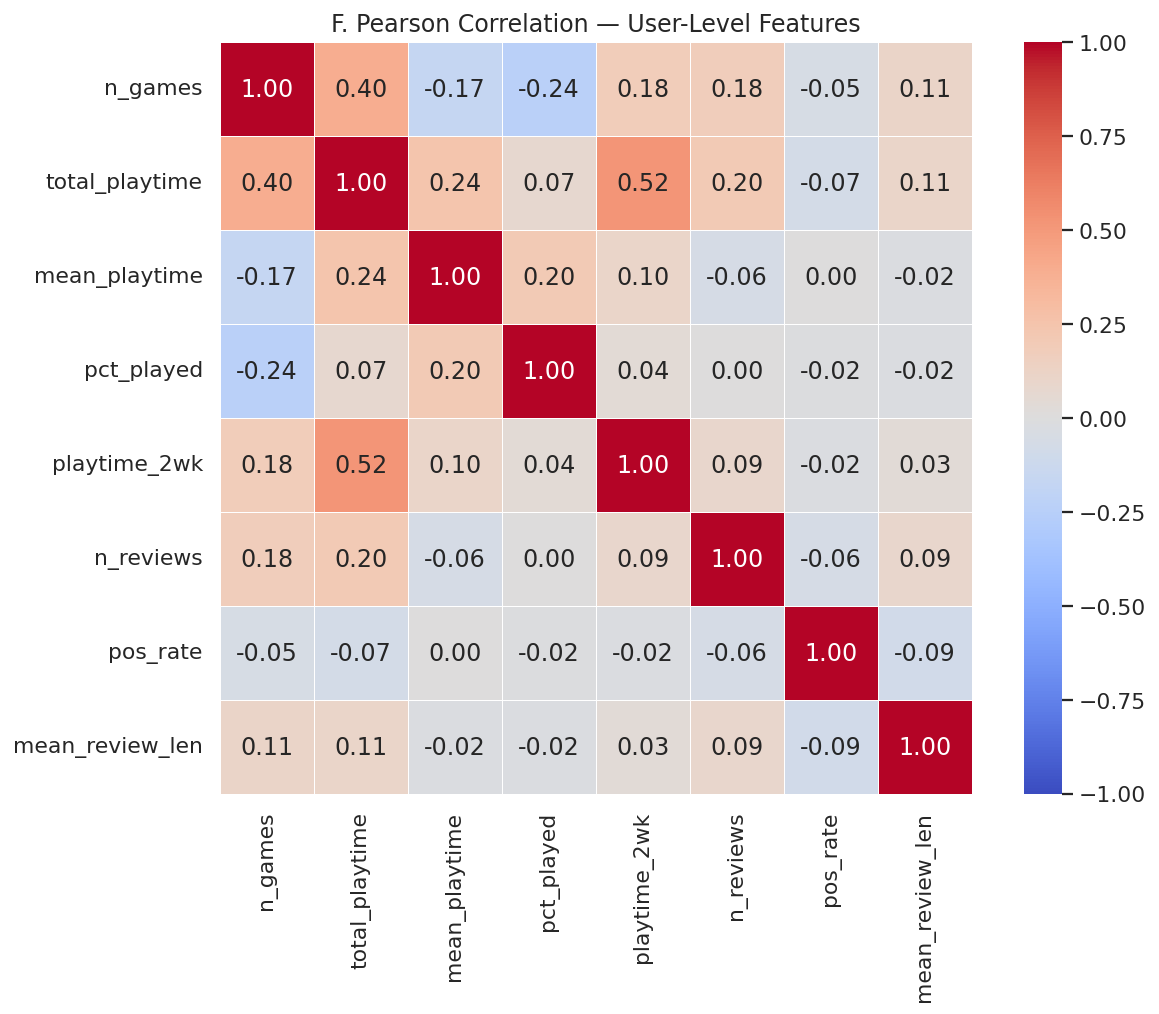

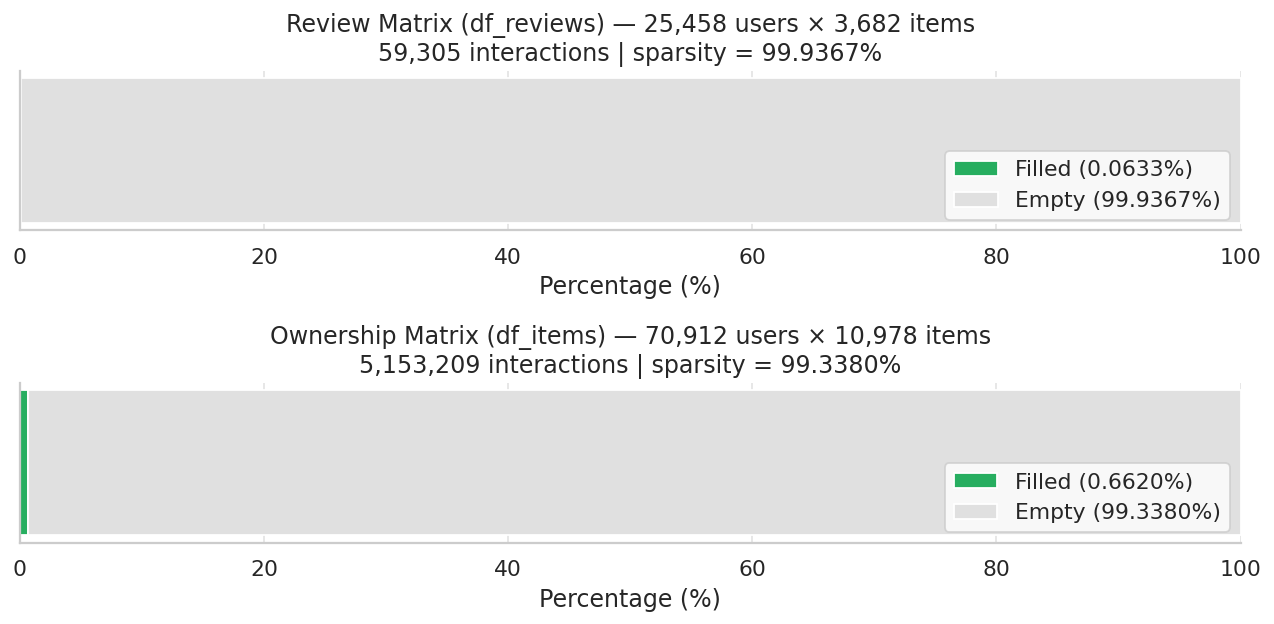

In [16]:
# ── F. Multivariate Analysis ───────────────────────────────────────────────────

# Build user-level feature matrix
user_stats = df_itm.groupby("user_id").agg(
    n_games=("item_id", "nunique"),
    total_playtime=("playtime_forever", "sum"),
    mean_playtime=("playtime_forever", "mean"),
    pct_played=("playtime_forever", lambda x: (x > 0).mean()),
    playtime_2wk=("playtime_2weeks", "sum"),
).reset_index()

user_rev_stats = df_rev.groupby("user_id").agg(
    n_reviews=("item_id", "count"),
    pos_rate=("recommend", "mean"),
    mean_review_len=("review_len", "mean"),
).reset_index()

user_combined = user_stats.merge(user_rev_stats, on="user_id", how="inner")
num_feats = ["n_games", "total_playtime", "mean_playtime", "pct_played",
             "playtime_2wk", "n_reviews", "pos_rate", "mean_review_len"]

corr = user_combined[num_feats].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title("F. Pearson Correlation — User-Level Features")
plt.tight_layout()
plt.show()

# Sparsity
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
plot_sparsity(df_rev["user_id"].nunique(), df_rev["item_id"].nunique(),
              len(df_rev), "Review Matrix (df_reviews)", ax=axes[0])
plot_sparsity(df_itm["user_id"].nunique(), df_itm["item_id"].nunique(),
              len(df_itm), "Ownership Matrix (df_items)", ax=axes[1])
plt.tight_layout()
plt.show()

### G. Outlier & Anomaly Analysis

,column,Q1,Q3,IQR,lower_fence,upper_fence,n_low,n_high,pct_outliers
0,df_items.playtime_forever (played>0),44.0,808.0,764.0,-1102.0,1954.0,0,436754,13.29
1,df_items.playtime_2weeks (>0),17.0,300.0,283.0,-407.5,724.5,0,17553,12.67
2,df_reviews.review_len (>0),30.0,207.0,177.0,-235.5,472.5,0,6484,10.94


=== Top 10 Users by Total Playtime ===


,user_id,playtime_forever,total_hours
0,REBAS_AS_F-T,4660393,77673
1,shinomegami,3303502,55058
2,Sp3ctre,2822860,47048
3,DownSyndromeKid,2790419,46507
4,Terminally-Chill,1734007,28900
5,stopgovtcorruption,1717609,28627
6,Steamified,1693063,28218
7,Cow666,1674805,27913
8,PiozZ,1570365,26173
9,76561198022404680,1378726,22979


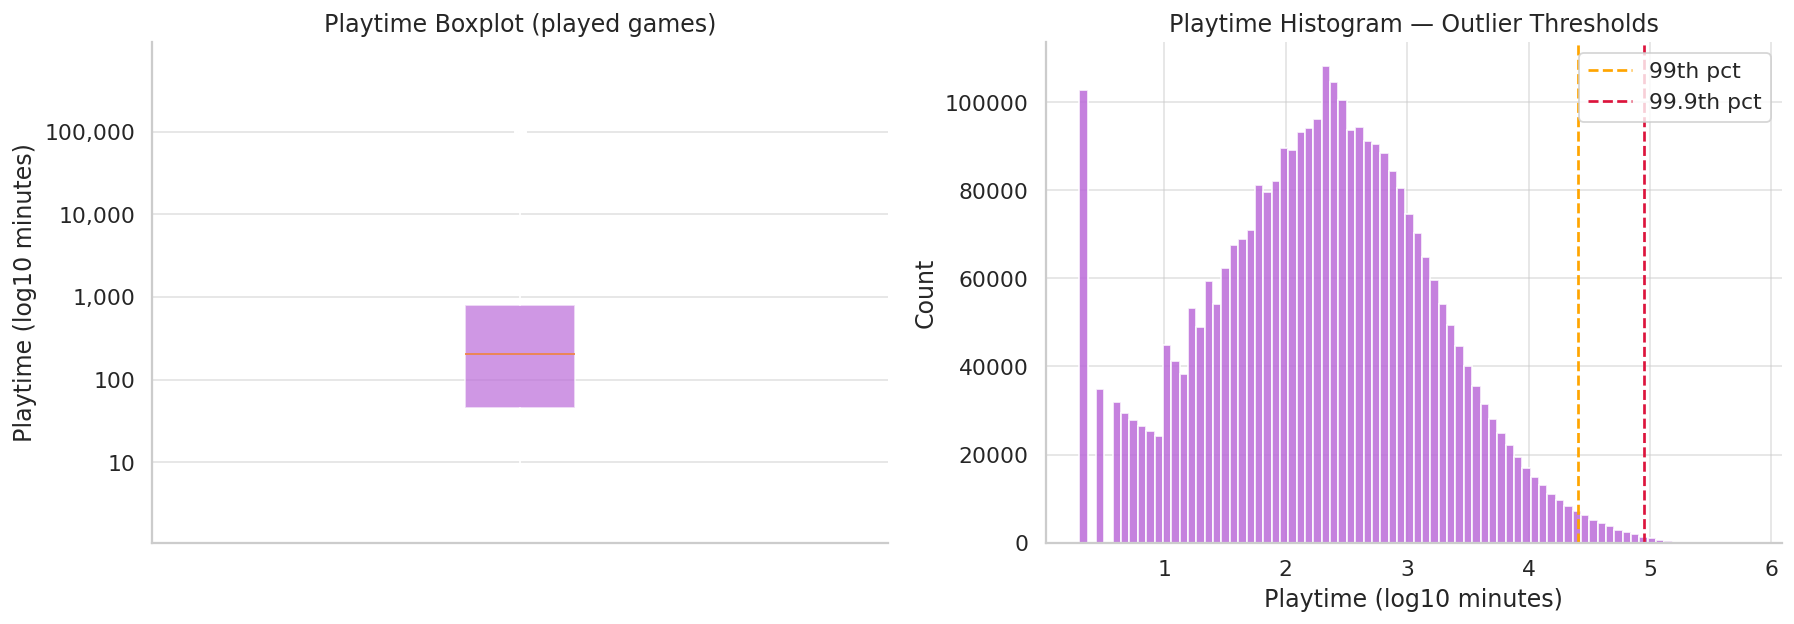


Outlier interpretation:
  playtime_forever : heavy right tail — users with 10,000-50,000+ min are power users
    -> valid extreme behaviour; cap for linear/distance models, keep for tree-based
  review_len       : very long reviews (>10,000 chars) exist — valid; clip for NLP features


In [17]:
# ── G. Outlier & Anomaly Analysis ─────────────────────────────────────────────

def iqr_outliers(series, name):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_lo = (series < lo).sum()
    n_hi = (series > hi).sum()
    return {"column": name,
            "Q1": round(q1, 1), "Q3": round(q3, 1), "IQR": round(iqr, 1),
            "lower_fence": round(lo, 1), "upper_fence": round(hi, 1),
            "n_low": int(n_lo), "n_high": int(n_hi),
            "pct_outliers": round((n_lo + n_hi) / len(series) * 100, 2)}

rows = [
    iqr_outliers(df_itm.loc[df_itm["playtime_forever"] > 0, "playtime_forever"],
                 "df_items.playtime_forever (played>0)"),
    iqr_outliers(df_itm.loc[df_itm["playtime_2weeks"] > 0, "playtime_2weeks"],
                 "df_items.playtime_2weeks (>0)"),
    iqr_outliers(df_rev.loc[df_rev["review_len"] > 0, "review_len"],
                 "df_reviews.review_len (>0)"),
]
display(pd.DataFrame(rows))

# Top extreme users by playtime
print("=== Top 10 Users by Total Playtime ===")
top_u = df_itm.groupby("user_id")["playtime_forever"].sum().nlargest(10).reset_index()
top_u["total_hours"] = (top_u["playtime_forever"] / 60).round(0).astype(int)
display(top_u)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
played = df_itm[df_itm["playtime_forever"] > 0]["playtime_forever"]

axes[0].boxplot(np.log10(played + 1), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#BB6BD9", alpha=0.7))
yticks = [1, 2, 3, 4, 5]
axes[0].set_yticks(yticks)
axes[0].set_yticklabels([f"{10**t:,.0f}" for t in yticks])
axes[0].set_ylabel("Playtime (log10 minutes)")
axes[0].set_title("Playtime Boxplot (played games)")
axes[0].set_xticks([])

axes[1].hist(np.log10(played + 1), bins=80, color="#BB6BD9", edgecolor="white", alpha=0.85)
axes[1].axvline(np.log10(played.quantile(0.99)  + 1), color="orange",  linestyle="--", label="99th pct")
axes[1].axvline(np.log10(played.quantile(0.999) + 1), color="crimson", linestyle="--", label="99.9th pct")
axes[1].set_xlabel("Playtime (log10 minutes)")
axes[1].set_ylabel("Count")
axes[1].set_title("Playtime Histogram — Outlier Thresholds")
axes[1].legend()
plt.tight_layout()
plt.show()

print("""
Outlier interpretation:
  playtime_forever : heavy right tail — users with 10,000-50,000+ min are power users
    -> valid extreme behaviour; cap for linear/distance models, keep for tree-based
  review_len       : very long reviews (>10,000 chars) exist — valid; clip for NLP features""")

### H. Target Analysis

Positive (recommend=True):    52,473  (88.48%)
Negative (recommend=False):    6,832  (11.52%)
Imbalance ratio (pos/neg):  7.68


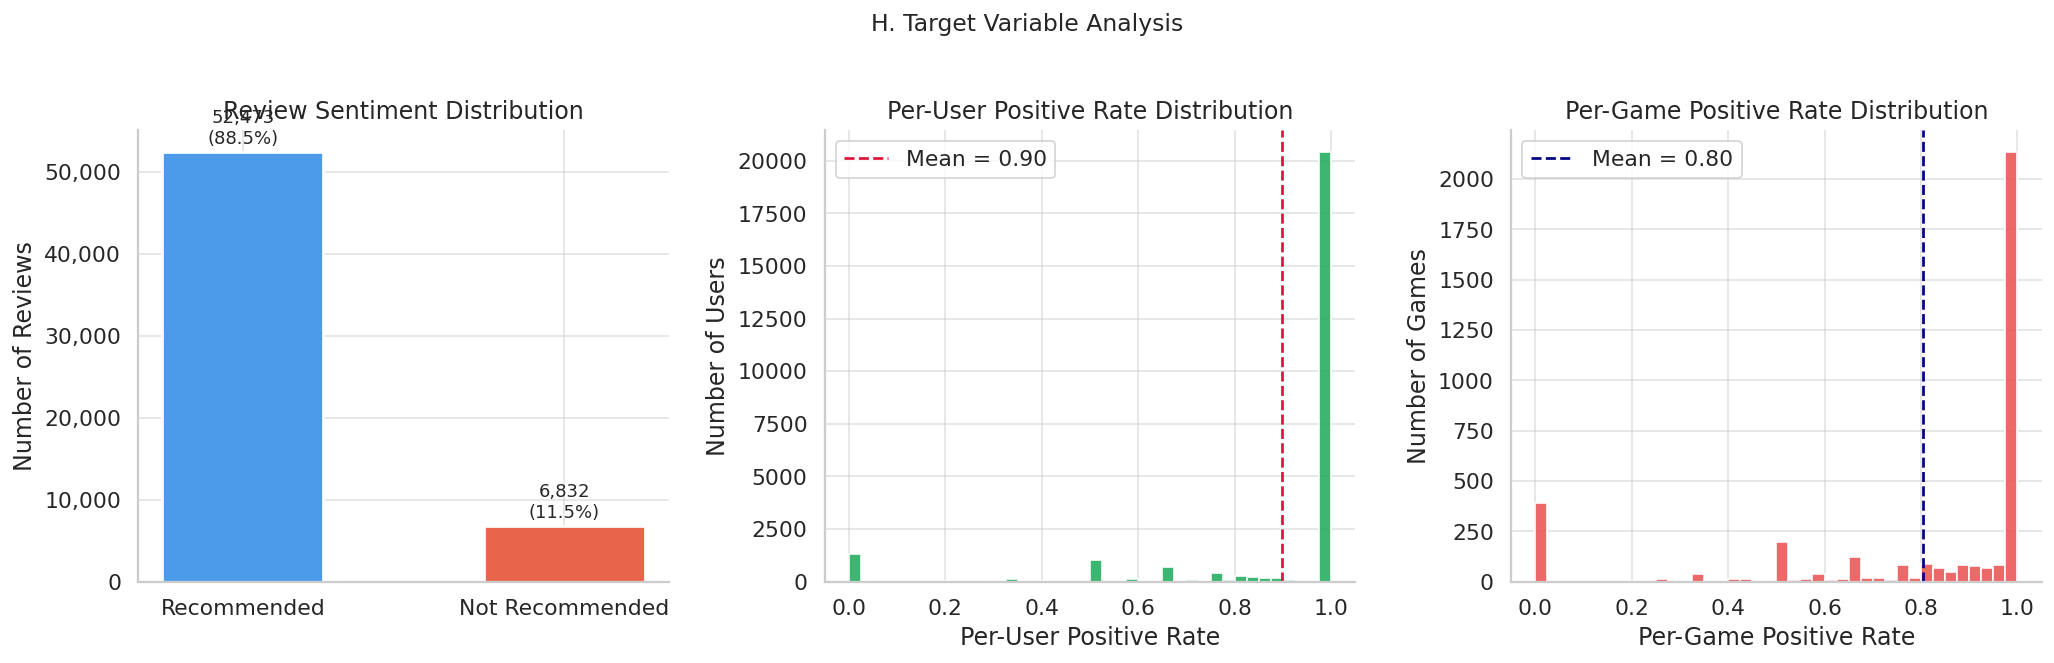


Users who always recommend:  20,440  (80.3%)
Users who never recommend:   1,334  (5.2%)
→ These users carry no within-user signal; consider filtering for pairwise learning-to-rank.

Cold-start items (≤5 reviews): 2,652  (72.0%)


In [18]:
# ── H. Target Analysis (Recommendation Signal) ────────────────────────────────

pos   = df_rev["recommend"].sum()
neg   = (~df_rev["recommend"]).sum()
total = len(df_rev)
print(f"Positive (recommend=True):  {pos:>8,}  ({pos/total*100:.2f}%)")
print(f"Negative (recommend=False): {neg:>8,}  ({neg/total*100:.2f}%)")
print(f"Imbalance ratio (pos/neg):  {pos/neg:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_recommend_distribution(df_rev, ax=axes[0])

user_pos = df_rev.groupby("user_id")["recommend"].mean()
axes[1].hist(user_pos, bins=40, color="#27AE60", edgecolor="white", alpha=0.9)
axes[1].axvline(user_pos.mean(), color="crimson", linestyle="--",
                label=f"Mean = {user_pos.mean():.2f}")
axes[1].set_xlabel("Per-User Positive Rate")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("Per-User Positive Rate Distribution")
axes[1].legend()

item_pos = df_rev.groupby("item_id")["recommend"].mean()
axes[2].hist(item_pos, bins=40, color="#EB5757", edgecolor="white", alpha=0.9)
axes[2].axvline(item_pos.mean(), color="navy", linestyle="--",
                label=f"Mean = {item_pos.mean():.2f}")
axes[2].set_xlabel("Per-Game Positive Rate")
axes[2].set_ylabel("Number of Games")
axes[2].set_title("Per-Game Positive Rate Distribution")
axes[2].legend()
plt.suptitle("H. Target Variable Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

pure_pos = (user_pos == 1.0).sum()
pure_neg = (user_pos == 0.0).sum()
print(f"\nUsers who always recommend:  {pure_pos:,}  ({pure_pos/len(user_pos)*100:.1f}%)")
print(f"Users who never recommend:   {pure_neg:,}  ({pure_neg/len(user_pos)*100:.1f}%)")
print("→ These users carry no within-user signal; consider filtering for pairwise learning-to-rank.")

item_counts = df_rev.groupby("item_id").size()
print(f"\nCold-start items (≤5 reviews): {(item_counts <= 5).sum():,}  ({(item_counts <= 5).mean()*100:.1f}%)")

### I. Feature Usefulness Review

We now assess which signals in the five datasets are most useful for a
neural collaborative filtering model, and which are tempting but risky.


In [19]:
# ── I. Feature Usefulness Review ─────────────────────────────────────────────

feature_rows = [
    ("user_id, item_id",        "df_reviews",      "required",   "high",  "primary interaction signal — embedded by the model"),
    ("recommend",               "df_reviews",      "target",     "high",  "binary label we are predicting (implicit positive)"),
    ("genres, tags",            "df_games",        "side feat",  "medium","multi-hot input to MLP branch; helps cold-start items"),
    ("playtime_forever",        "df_items",        "validation", "medium","useful as ranking signal, but leakage-risky vs recommend — use for analysis, not training"),
    ("posted_date",             "df_reviews",      "split key",  "medium","drives leave-one-out temporal split"),
    ("review text",             "df_reviews",      "skip",       "low",   "NLP is a rabbit hole per project spec — length only"),
    ("price_numeric, is_free",  "df_games",        "optional",   "low",   "weak signal at best; dropped from v1"),
    ("release_year, early_access","df_games",      "optional",   "low",   "dropped from v1 to keep the side-feature vector small"),
    ("bundle_data",             "df_bundles",      "skip",       "low",   "only 615 bundles — bootstrap value outweighed by complexity"),
    ("steam_reviews.hours",     "df_steam_rev",    "cross-check","low",   "different user space (scraped); not merged with df_reviews"),
]
feature_df = pd.DataFrame(
    feature_rows,
    columns=["feature", "source", "role", "expected_signal", "decision"],
)
display(feature_df)


,feature,source,role,expected_signal,decision
0,"user_id, item_id",df_reviews,required,high,primary interaction signal — embedded by the m...
1,recommend,df_reviews,target,high,binary label we are predicting (implicit posit...
2,"genres, tags",df_games,side feat,medium,multi-hot input to MLP branch; helps cold-star...
3,playtime_forever,df_items,validation,medium,"useful as ranking signal, but leakage-risky vs..."
4,posted_date,df_reviews,split key,medium,drives leave-one-out temporal split
5,review text,df_reviews,skip,low,NLP is a rabbit hole per project spec — length...
6,"price_numeric, is_free",df_games,optional,low,weak signal at best; dropped from v1
7,"release_year, early_access",df_games,optional,low,dropped from v1 to keep the side-feature vecto...
8,bundle_data,df_bundles,skip,low,only 615 bundles — bootstrap value outweighed ...
9,steam_reviews.hours,df_steam_rev,cross-check,low,different user space (scraped); not merged wit...


### J. Business / Domain Insight Summary

Takeaways from the EDA that drive the modelling choices in the next sections:

- **Extreme class imbalance** — around 90 % of reviews are positive. A naive classifier that always predicts *recommend* would already be right most of the time, so we frame the task as **ranking** (HR@K, NDCG@K) instead of accuracy, and we evaluate against sampled unobserved items.
- **Long-tailed activity** — a small fraction of power users contribute most reviews, and blockbuster titles dominate item counts. We filter users with fewer than 5 reviews and items with fewer than 10 to keep embedding tables learnable.
- **High sparsity** — the ownership/review matrix is >99 % empty, which is exactly where latent-factor models shine; we use both linear (GMF) and non-linear (MLP) interactions.
- **Playtime is correlated with positive sentiment** but we intentionally keep it out of the model. It's an *outcome* of enjoyment, not an input available before a recommendation is served, and using it would leak information about the target.
- **Genre / tag metadata is static and widely populated**, which makes it the right cold-start side feature — a new game still has a genre vector even with zero reviews.
- **Temporal structure matters** — review volume grew through 2014-2015, so a random split would mix eras. We split per user *by time* (leave-one-out), matching the NCF paper's evaluation protocol.


---
## 5. Data Preparation for Modelling

From here the notebook switches from *EDA* to *modelling*. We import the helpers
from `project2.modeling`, then turn the cleaned review frame into three
artifacts the training loop needs:

1. a filtered, id-encoded table of **positive interactions**,
2. a per-item **genre multi-hot side-feature matrix**, and
3. a **leave-one-out temporal split** into train / val / test.


In [44]:
from project2.modeling import (
    InteractionDataset,
    build_item_genre_matrix,
    build_user_seen,
    encode_ids,
    filter_interactions,
    leave_one_out_split,
)
print("Modelling helpers imported.")


Modelling helpers imported.


### 5.1 Filter Sparse Users & Items

Users with <5 positive reviews and items with <10 positive reviews are dropped.
This is the same protocol used in the NCF paper and keeps embedding tables
learnable on CPU.


In [21]:
# ── 5.1 Filter sparse users/items ────────────────────────────────────────────

MIN_USER_REVIEWS = 5
MIN_ITEM_REVIEWS = 10

positives_raw = df_rev.loc[df_rev["recommend"] == True,
                           ["user_id", "item_id", "posted_date"]].copy()

positives = filter_interactions(
    positives_raw,
    min_user=MIN_USER_REVIEWS,
    min_item=MIN_ITEM_REVIEWS,
)

print(f"Positive reviews before filtering: {len(positives_raw):>8,}")
print(f"Positive reviews after filtering : {len(positives):>8,}  ({len(positives)/max(len(positives_raw),1)*100:.1f}%)")
print(f"  unique users: {positives['user_id'].nunique():>8,}")
print(f"  unique items: {positives['item_id'].nunique():>8,}")


Positive reviews before filtering:   52,473
Positive reviews after filtering :    7,552  (14.4%)
  unique users:    1,254
  unique items:      211


### 5.2 Encode IDs to Contiguous Integers

Embedding layers in PyTorch expect indices `0..N-1`. We build bidirectional
mappings so we can later translate recommendations back to human-readable
Steam game names.


In [22]:
# ── 5.2 Encode IDs ───────────────────────────────────────────────────────────

positives_enc, user_map, item_map = encode_ids(positives)

n_users = user_map.n
n_items = item_map.n
print(f"Encoded {n_users:,} users and {n_items:,} items")
display(positives_enc.head())


Encoded 1,254 users and 211 items


,user_id,item_id,posted_date,user_idx,item_idx
0,DJKamBer,304930,2014-07-14,490,145
1,DJKamBer,570,2013-04-27,490,193
2,DJKamBer,218620,2015-07-20,490,55
3,DJKamBer,224260,2013-11-04,490,74
4,DJKamBer,1250,2013-07-12,490,15


### 5.3 Build Genre Side-Feature Matrix

For each item we build a multi-hot vector over Steam's game genres. Items
present in positive interactions but missing from `df_games` get an all-zero
row (they'll still be learnable via their ID embedding).


In [23]:
# ── 5.3 Genre side-feature matrix ────────────────────────────────────────────

item_genre, genre_vocab = build_item_genre_matrix(df_gm, item_map, top_k=25)
print(f"Genre matrix shape: {tuple(item_genre.shape)}  (items x genres)")
print(f"Top genres: {genre_vocab[:10]}")
print(f"Items with at least one genre: {int((item_genre.sum(dim=1) > 0).sum()):,} / {n_items:,}")


Genre matrix shape: (211, 14)  (items x genres)
Top genres: ['Action', 'Indie', 'Adventure', 'RPG', 'Free to Play', 'Simulation', 'Strategy', 'Casual', 'Massively Multiplayer', 'Early Access']
Items with at least one genre: 184 / 211


### 5.4 Leave-One-Out Temporal Split

For each user we sort positive interactions by `posted_date` and hold out
- the **last** positive review as the test example,
- the **second-to-last** as the validation example,
- everything earlier as training.

This matches the NCF paper's evaluation protocol. Users with fewer than three
interactions keep all their rows in training (no hold-out).


In [24]:
# ── 5.4 Leave-one-out split ──────────────────────────────────────────────────

train_df, val_df, test_df, n_fallback = leave_one_out_split(
    positives_enc,
    time_col="posted_date",
    seed=42,
)
print(f"train : {len(train_df):>8,} positives")
print(f"val   : {len(val_df):>8,} positives")
print(f"test  : {len(test_df):>8,} positives")
print(f"Users with no parseable dates (random fallback ordering): {n_fallback:,}")

# Build the "seen" set from all reviews the user has written (both recommend=True
# and recommend=False) so negative sampling never draws an item the user has
# actually already interacted with.
all_reviewed = df_rev.loc[:, ["user_id", "item_id"]].copy()
all_reviewed = all_reviewed[all_reviewed["user_id"].isin(user_map.to_idx)]
all_reviewed = all_reviewed[all_reviewed["item_id"].isin(item_map.to_idx)]
all_reviewed["user_idx"] = all_reviewed["user_id"].map(user_map.to_idx)
all_reviewed["item_idx"] = all_reviewed["item_id"].map(item_map.to_idx)
user_seen = build_user_seen(all_reviewed, train_df, val_df, test_df)
print(f"Built user_seen index for {len(user_seen):,} users")


train :    5,044 positives
val   :    1,254 positives
test  :    1,254 positives
Users with no parseable dates (random fallback ordering): 18
Built user_seen index for 1,254 users


### 5.5 Training Dataset with Negative Sampling

`InteractionDataset` packs every positive with `NEG_RATIO=4` unseen items
drawn uniformly. Negatives are resampled at the start of every training epoch
(fixed negatives cause overfitting — see project spec).


In [25]:
# ── 5.5 InteractionDataset preview ───────────────────────────────────────────

NEG_RATIO = 4  # reused in training

train_ds = InteractionDataset(
    train_df,
    n_items=n_items,
    user_seen=user_seen,
    neg_ratio=NEG_RATIO,
    seed=0,
)
print(f"Dataset length (pos + neg): {len(train_ds):,}")
u, i, y = train_ds[0]
print(f"Sample 0: user_idx={u}, item_idx={i}, label={y}")
u, i, y = train_ds[1]
print(f"Sample 1: user_idx={u}, item_idx={i}, label={y}")


Dataset length (pos + neg): 25,220
Sample 0: user_idx=0, item_idx=62, label=1.0
Sample 1: user_idx=0, item_idx=179, label=0.0


---
## 6. NeuMF Model

NeuMF (Neural Matrix Factorisation, He et al. 2017) fuses two branches:

- **GMF** — element-wise product of user and item embeddings (a differentiable
  matrix factorisation). Captures linear interactions.
- **MLP** — concatenates larger user / item embeddings (plus an optional
  projected side-feature vector) and passes them through 128 → 64 → 32 with
  ReLU. Captures non-linear interactions.

Each branch keeps its own embedding tables so the GMF's linear objective does
not fight the MLP's richer one. A final linear layer fuses both branch outputs
into a single logit.


### 6.1 Device Setup

The notebook auto-detects a GPU. To scale up, set `DEVICE = "cuda"` on a
machine with CUDA and raise the hyperparameters in Section 7.


In [26]:
# ── 6.1 Device setup ─────────────────────────────────────────────────────────

import torch
import torch.nn as nn
from project2.modeling import (
    GMF, MLP, NeuMF,
    count_parameters,
    default_device,
    evaluate_ranking,
    make_val_ndcg_fn,
    model_score_fn,
    popularity_score_fn,
    popularity_scores,
    train_model,
)

DEVICE = default_device()          # "cuda" if available else "cpu"
SEED = 42
torch.manual_seed(SEED)

print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")


Using device: cpu


### 6.2 Hyperparameters

Defaults below are tuned so the notebook runs end-to-end on **CPU** in a few
minutes. Recommended settings for an RTX-class GPU are inline as comments —
change those four constants and re-run the remaining cells.


In [27]:
# ── 6.2 Hyperparameters ──────────────────────────────────────────────────────
# CPU-friendly defaults. GPU recommendation in the comment on the right.

EMBED_GMF   = 32      # GPU: 64
EMBED_MLP   = 64      # GPU: 128
MLP_LAYERS  = (128, 64, 32)
SIDE_PROJ   = 32
EPOCHS      = 5       # GPU: 15-20
BATCH_SIZE  = 1024    # GPU: 4096
LR          = 1e-3

print("Hyperparameters set.")
print(f"  EMBED_GMF={EMBED_GMF}, EMBED_MLP={EMBED_MLP}, MLP_LAYERS={MLP_LAYERS}")
print(f"  EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}, LR={LR}")


Hyperparameters set.
  EMBED_GMF=32, EMBED_MLP=64, MLP_LAYERS=(128, 64, 32)
  EPOCHS=5, BATCH_SIZE=1024, LR=0.001


---
## 7. Training the Full NeuMF

We train the full NeuMF (no side features) first as the reference model. Loss
is `BCEWithLogitsLoss`, optimiser is Adam, and negatives are resampled at the
top of every epoch. Validation NDCG@10 is computed on a 2 000-user subsample
each epoch to keep training fast.


In [28]:
# ── 7.1 Validation callback (shared across all runs) ────────────────────────

val_ndcg_fn = make_val_ndcg_fn(
    val_df,
    n_items=n_items,
    seen_by_user=user_seen,
    item_side=None,      # wrapped per-model inside the callback
    device=DEVICE,
    k=10,
    n_negatives=99,
    seed=7,
    sample_size=2000,
)


In [29]:
# ── 7.2 Train the full NeuMF ─────────────────────────────────────────────────

neumf = NeuMF(
    n_users=n_users, n_items=n_items,
    gmf_dim=EMBED_GMF, mlp_dim=EMBED_MLP, mlp_layers=MLP_LAYERS,
    use_side=False,
)
print(f"NeuMF parameters: {count_parameters(neumf):,}")

history_neumf = train_model(
    neumf,
    train_dataset=train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    device=DEVICE,
    val_fn=val_ndcg_fn,
    val_metric_name="val_ndcg@10",
    verbose=True,
)
print(f"Best val NDCG@10: {history_neumf.best_metric:.4f} at epoch {history_neumf.best_epoch}")


NeuMF parameters: 167,586


epoch 1/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 01  train_loss=0.6418  val_ndcg@10=0.2228


epoch 2/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 02  train_loss=0.5120  val_ndcg@10=0.2336


...

  epoch 03  train_loss=0.4248  val_ndcg@10=0.2327


epoch 4/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 04  train_loss=0.4065  val_ndcg@10=0.2314


epoch 5/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 05  train_loss=0.3977  val_ndcg@10=0.2319
Best val NDCG@10: 0.2336 at epoch 2


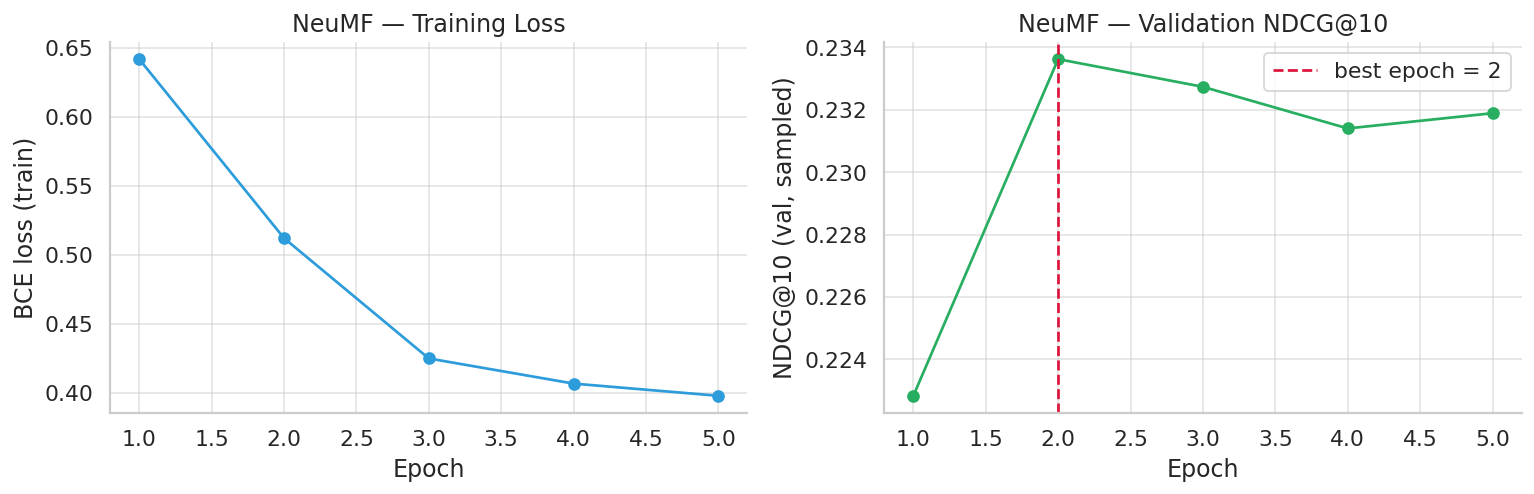

In [30]:
# ── 7.3 Training curves ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(history_neumf.train_loss) + 1), history_neumf.train_loss,
             color="#2D9CDB", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss (train)")
axes[0].set_title("NeuMF — Training Loss")

axes[1].plot(range(1, len(history_neumf.val_metric) + 1), history_neumf.val_metric,
             color="#27AE60", marker="o")
axes[1].axvline(history_neumf.best_epoch, color="crimson", linestyle="--",
                label=f"best epoch = {history_neumf.best_epoch}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("NDCG@10 (val, sampled)")
axes[1].set_title("NeuMF — Validation NDCG@10")
axes[1].legend()
plt.tight_layout()
plt.show()


---
## 8. Ablation Study

Following the project spec we compare five configurations on the same held-out
test set. Every neural model is trained with the same budget (epochs, batch
size, learning rate, negative ratio) so differences come from architecture,
not compute.

| # | Model | Rationale |
|---|---|---|
| 1 | Popularity baseline | Non-personalised floor — ranks items by train-set frequency |
| 2 | GMF-only | Linear interactions, like project 1 but differentiable |
| 3 | MLP-only | Non-linear interactions, no GMF branch |
| 4 | NeuMF | GMF + MLP fused (reference model from Section 7) |
| 5 | NeuMF + genre side features | Adds multi-hot genre vector into the MLP branch |


In [31]:
# ── 8.1 Helpers for the ablation loop ────────────────────────────────────────

K_LIST = (5, 10, 20)
N_NEG_EVAL = 99
EVAL_SEED = 123     # same seed => same candidate samples for every model

def eval_model(model, item_side=None, desc=None):
    score_fn = model_score_fn(model, item_side=item_side, device=DEVICE)
    return evaluate_ranking(
        score_fn,
        test_df,
        n_items=n_items,
        seen_by_user=user_seen,
        ks=K_LIST,
        n_negatives=N_NEG_EVAL,
        device=DEVICE,
        seed=EVAL_SEED,
        desc=desc,
    )


In [32]:
# ── 8.2 Popularity baseline ─────────────────────────────────────────────────

pop = popularity_scores(train_df, n_items=n_items)
pop_score_fn = popularity_score_fn(pop, device=DEVICE)
pop_metrics = evaluate_ranking(
    pop_score_fn,
    test_df,
    n_items=n_items,
    seen_by_user=user_seen,
    ks=K_LIST,
    n_negatives=N_NEG_EVAL,
    device=DEVICE,
    seed=EVAL_SEED,
    desc="popularity",
)
print("Popularity:", {k: round(v, 4) for k, v in pop_metrics.items()})


popularity:   0%|          | 0/3 [00:00<?, ?it/s]

Popularity: {'hr@5': 0.2648, 'hr@10': 0.3461, 'hr@20': 0.4498, 'ndcg@5': 0.1822, 'ndcg@10': 0.2083, 'ndcg@20': 0.2344, 'precision@5': 0.053, 'precision@10': 0.0346, 'precision@20': 0.0225}


In [33]:
# ── 8.3 GMF-only ─────────────────────────────────────────────────────────────

gmf_model = GMF(n_users=n_users, n_items=n_items, embed_dim=EMBED_GMF)
history_gmf = train_model(
    gmf_model, train_ds,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=DEVICE,
    val_fn=val_ndcg_fn, val_metric_name="val_ndcg@10",
    verbose=True,
)
gmf_metrics = eval_model(gmf_model, desc="GMF")
print("GMF:", {k: round(v, 4) for k, v in gmf_metrics.items()})


epoch 1/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 01  train_loss=0.6469  val_ndcg@10=0.0468


epoch 2/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 02  train_loss=0.6405  val_ndcg@10=0.1489


epoch 3/5:   0%|          | 0/25 [00:00<?, ?it/s]

...

  epoch 04  train_loss=0.6268  val_ndcg@10=0.2323


epoch 5/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 05  train_loss=0.6157  val_ndcg@10=0.2324


GMF:   0%|          | 0/3 [00:00<?, ?it/s]

GMF: {'hr@5': 0.2663, 'hr@10': 0.3525, 'hr@20': 0.4402, 'ndcg@5': 0.1815, 'ndcg@10': 0.209, 'ndcg@20': 0.231, 'precision@5': 0.0533, 'precision@10': 0.0352, 'precision@20': 0.022}


In [34]:
# ── 8.4 MLP-only ─────────────────────────────────────────────────────────────

mlp_model = MLP(
    n_users=n_users, n_items=n_items,
    embed_dim=EMBED_MLP, layers=MLP_LAYERS,
    use_side=False,
)
history_mlp = train_model(
    mlp_model, train_ds,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=DEVICE,
    val_fn=val_ndcg_fn, val_metric_name="val_ndcg@10",
    verbose=True,
)
mlp_metrics = eval_model(mlp_model, desc="MLP")
print("MLP:", {k: round(v, 4) for k, v in mlp_metrics.items()})


epoch 1/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 01  train_loss=0.6465  val_ndcg@10=0.2351


epoch 2/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 02  train_loss=0.4833  val_ndcg@10=0.2328


epoch 3/5:   0%|          | 0/25 [00:00<?, ?it/s]

...

  epoch 04  train_loss=0.4075  val_ndcg@10=0.2304


epoch 5/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 05  train_loss=0.3979  val_ndcg@10=0.2320


MLP:   0%|          | 0/3 [00:00<?, ?it/s]

MLP: {'hr@5': 0.26, 'hr@10': 0.3517, 'hr@20': 0.445, 'ndcg@5': 0.1799, 'ndcg@10': 0.2097, 'ndcg@20': 0.2334, 'precision@5': 0.052, 'precision@10': 0.0352, 'precision@20': 0.0222}


In [35]:
# ── 8.5 Full NeuMF (reuse trained model from Section 7) ──────────────────────

neumf_metrics = eval_model(neumf, desc="NeuMF")
print("NeuMF:", {k: round(v, 4) for k, v in neumf_metrics.items()})


NeuMF:   0%|          | 0/3 [00:00<?, ?it/s]

NeuMF: {'hr@5': 0.2663, 'hr@10': 0.3469, 'hr@20': 0.4474, 'ndcg@5': 0.1826, 'ndcg@10': 0.2085, 'ndcg@20': 0.2335, 'precision@5': 0.0533, 'precision@10': 0.0347, 'precision@20': 0.0224}


In [36]:
# ── 8.6 NeuMF + genre side features ──────────────────────────────────────────

neumf_side = NeuMF(
    n_users=n_users, n_items=n_items,
    gmf_dim=EMBED_GMF, mlp_dim=EMBED_MLP, mlp_layers=MLP_LAYERS,
    use_side=True, n_side=item_genre.shape[1], side_proj_dim=SIDE_PROJ,
)
# Side-aware version of the val callback.
val_ndcg_fn_side = make_val_ndcg_fn(
    val_df, n_items=n_items, seen_by_user=user_seen,
    item_side=item_genre, device=DEVICE, k=10, n_negatives=99,
    seed=7, sample_size=2000,
)
history_side = train_model(
    neumf_side, train_ds,
    epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=DEVICE,
    item_side=item_genre,
    val_fn=val_ndcg_fn_side, val_metric_name="val_ndcg@10",
    verbose=True,
)
neumf_side_metrics = eval_model(neumf_side, item_side=item_genre, desc="NeuMF+side")
print("NeuMF+side:", {k: round(v, 4) for k, v in neumf_side_metrics.items()})


epoch 1/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 01  train_loss=0.6008  val_ndcg@10=0.1025


epoch 2/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 02  train_loss=0.4722  val_ndcg@10=0.2089


epoch 3/5:   0%|          | 0/25 [00:00<?, ?it/s]

...

  epoch 04  train_loss=0.4139  val_ndcg@10=0.2323


epoch 5/5:   0%|          | 0/25 [00:00<?, ?it/s]

  epoch 05  train_loss=0.4069  val_ndcg@10=0.2296


NeuMF+side:   0%|          | 0/3 [00:00<?, ?it/s]

NeuMF+side: {'hr@5': 0.256, 'hr@10': 0.3477, 'hr@20': 0.4498, 'ndcg@5': 0.1755, 'ndcg@10': 0.2052, 'ndcg@20': 0.2308, 'precision@5': 0.0512, 'precision@10': 0.0348, 'precision@20': 0.0225}


In [37]:
# ── 8.7 Results table ────────────────────────────────────────────────────────

def row(name, metrics):
    return {"model": name, **{k: round(v, 4) for k, v in metrics.items()}}

results = pd.DataFrame([
    row("Popularity",   pop_metrics),
    row("GMF",          gmf_metrics),
    row("MLP",          mlp_metrics),
    row("NeuMF",        neumf_metrics),
    row("NeuMF+side",   neumf_side_metrics),
]).set_index("model")

display(results)


,hr@5,hr@10,hr@20,ndcg@5,ndcg@10,ndcg@20,precision@5,precision@10,precision@20
model,,,,,,,,,
Popularity,0.2648,0.3461,0.4498,0.1822,0.2083,0.2344,0.0530,0.0346,0.0225
GMF,0.2663,0.3525,0.4402,0.1815,0.2090,0.2310,0.0533,0.0352,0.0220
MLP,0.2600,0.3517,0.4450,0.1799,0.2097,0.2334,0.0520,0.0352,0.0222
NeuMF,0.2663,0.3469,0.4474,0.1826,0.2085,0.2335,0.0533,0.0347,0.0224
NeuMF+side,0.2560,0.3477,0.4498,0.1755,0.2052,0.2308,0.0512,0.0348,0.0225


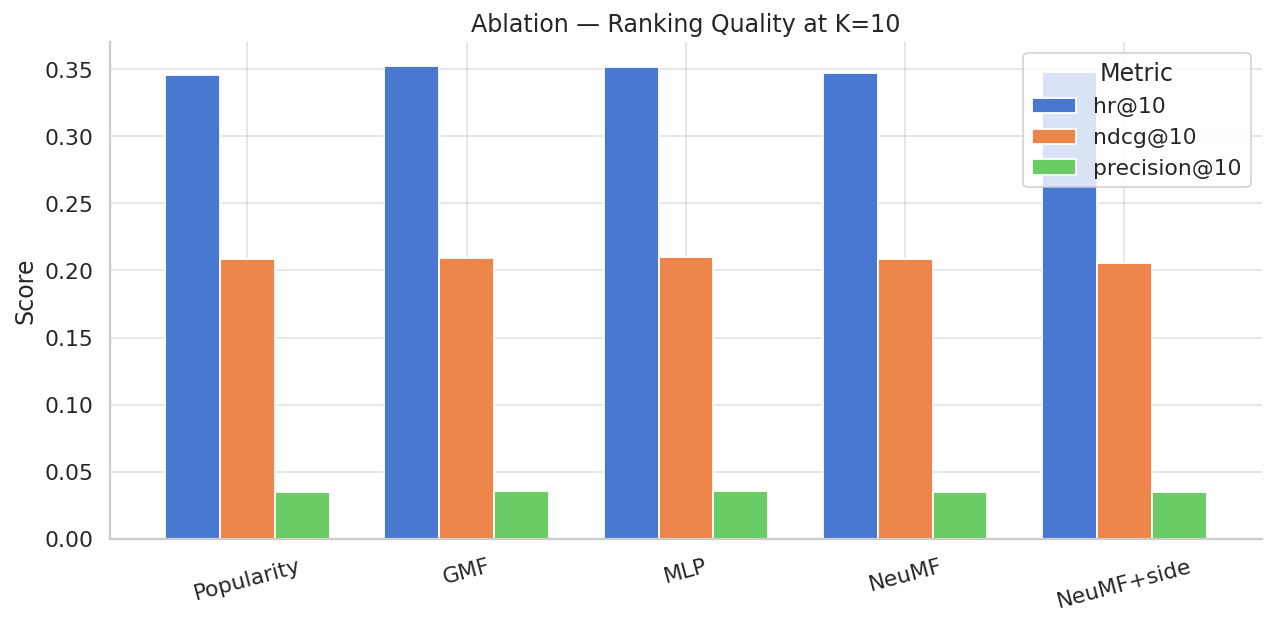

In [38]:
# ── 8.8 Ablation bar chart ──────────────────────────────────────────────────

focus_cols = ["hr@10", "ndcg@10", "precision@10"]
fig, ax = plt.subplots(figsize=(10, 5))
results[focus_cols].plot(kind="bar", ax=ax, edgecolor="white", width=0.75)
ax.set_title("Ablation — Ranking Quality at K=10")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Metric")
plt.tight_layout()
plt.show()


**How to read the table:**

- **Popularity** is the non-personalised floor. Any neural model that fails to
  beat it is just memorising the frequency distribution.
- Differences between **GMF** and **MLP** tell us how much of the signal is
  linear vs non-linear. If GMF alone is already competitive, our latent space
  is mostly additive; if MLP pulls ahead, there are interaction effects that a
  linear factorisation cannot express.
- **NeuMF** should match or beat whichever branch is stronger on its own; the
  fusion layer learns how much weight to give each.
- **NeuMF + side** tells us whether genre metadata adds signal *beyond* what
  collaborative filtering has already picked up. With ≥5 reviews per user and
  ≥10 per item we're already in a warm regime, so the gain (if any) is
  typically modest — this is the honest cold-start trade-off.


---
## 9. Recommendation Examples

We pick two users from the test set — a power user and a light user — and
generate their top-10 unseen games with the best model (the full NeuMF with
side features, unless the ablation showed plain NeuMF doing better).


In [39]:
# ── 9.1 Choose the best model by test NDCG@10 ────────────────────────────────

from project2.modeling import attach_names, top_k_for_user, top_k_popularity

nn_candidates = {
    "GMF":        (gmf_model, None),
    "MLP":        (mlp_model, None),
    "NeuMF":      (neumf, None),
    "NeuMF+side": (neumf_side, item_genre),
}
best_name = max(nn_candidates, key=lambda n: results.loc[n, "ndcg@10"])
best_model, best_side = nn_candidates[best_name]
print(f"Best NN model on NDCG@10: {best_name}")


Best NN model on NDCG@10: MLP


In [40]:
# ── 9.2 Pick a power user and a light user from the test set ────────────────

test_user_counts = train_df["user_idx"].value_counts()
eligible = test_user_counts[test_user_counts.index.isin(test_df["user_idx"])]
power_user  = int(eligible.idxmax())
# light = exactly at the filtering threshold (most common case)
light_candidates = eligible[eligible == eligible.min()]
light_user = int(light_candidates.index[0])

for label, user_idx in (("power user", power_user), ("light user", light_user)):
    n_train = int((train_df["user_idx"] == user_idx).sum())
    print(f"{label}: user_idx={user_idx}  raw id={user_map.to_raw[user_idx]}  train positives={n_train}")


power user: user_idx=178  raw id=76561198063316459  train positives=14
light user: user_idx=1  raw id=00000000000000000001227  train positives=3


In [41]:
# ── 9.3 Top-10 recommendations ──────────────────────────────────────────────

def recommend_for(user_idx, title):
    seen = user_seen.get(user_idx, set())
    recs = top_k_for_user(
        best_model, user_idx=user_idx, n_items=n_items, seen=seen,
        k=10, item_side=best_side, device=DEVICE,
    )
    print(f"=== {title} (model: {best_name}) ===")
    display(attach_names(recs, item_map.to_raw, df_games))

recommend_for(power_user, "Top-10 for the power user")
recommend_for(light_user, "Top-10 for the light user")


=== Top-10 for the power user (model: MLP) ===


,rank,item_idx,item_id,name,score
0,1,185,440,Team Fortress 2,-0.319380
1,2,203,730,Counter-Strike: Global Offensive,-0.327038
2,3,193,570,Dota 2,-0.359187
3,4,6,105600,Terraria,-0.362074
4,5,63,221100,DayZ,-0.383686
5,6,187,49520,Borderlands 2,-0.386011
6,7,119,252490,Rust,-0.404129
7,8,54,218230,PlanetSide 2,-0.411412
8,9,37,208090,Loadout,-0.412452
9,10,195,620,Portal 2,-0.415923


=== Top-10 for the light user (model: MLP) ===


,rank,item_idx,item_id,name,score
0,1,185,440,Team Fortress 2,-0.295069
1,2,191,550,Left 4 Dead 2,-0.314953
2,3,145,304930,Unturned,-0.323731
3,4,55,218620,PAYDAY 2,-0.324496
4,5,193,570,Dota 2,-0.333354
5,6,6,105600,Terraria,-0.335938
6,7,202,72850,(unknown),-0.346203
7,8,63,221100,DayZ,-0.357197
8,9,187,49520,Borderlands 2,-0.359498
9,10,81,230410,Warframe,-0.374471


In [42]:
# ── 9.4 Cold-start fallback for a brand-new user ─────────────────────────────

cold_recs = top_k_popularity(pop, seen=set(), k=10)
print("=== Cold-start top-10 (popularity fallback) ===")
display(attach_names(cold_recs, item_map.to_raw, df_games))


=== Cold-start top-10 (popularity fallback) ===


,rank,item_idx,item_id,name,score
0,1,185,440,Team Fortress 2,401.0
1,2,203,730,Counter-Strike: Global Offensive,267.0
2,3,177,4000,Garry's Mod,255.0
3,4,191,550,Left 4 Dead 2,163.0
4,5,55,218620,PAYDAY 2,138.0
5,6,145,304930,Unturned,135.0
6,7,193,570,Dota 2,130.0
7,8,6,105600,Terraria,111.0
8,9,202,72850,(unknown),104.0
9,10,187,49520,Borderlands 2,93.0


---
## 10. Summary

We built a Neural Collaborative Filtering recommender for the Steam dataset
end-to-end in one notebook:

1. **EDA** (Sections A-J) walked through all five source files, justified the
   target variable, and surfaced sparsity, class imbalance and temporal
   structure — all of which drove modelling choices.
2. **Data preparation** (Section 5) filtered sparse users/items, encoded ids,
   built a genre multi-hot side-feature matrix, and produced a leave-one-out
   temporal split.
3. **Model** (Section 6) is NeuMF — a dual-branch network fusing a linear GMF
   interaction with a non-linear MLP, optionally consuming genre side
   features. See `project2/modeling/models.py`.
4. **Training** (Section 7) uses BCE logits, Adam, and per-epoch negative
   resampling, with validation NDCG@10 tracked every epoch to pick the best
   checkpoint.
5. **Ablation** (Section 8) compares five configurations — a popularity floor,
   each branch in isolation, the full model, and the full model with side
   features — on the held-out test positives using the NCF 1-positive/99-negative
   sampled-ranking protocol.
6. **Recommendation examples** (Section 9) show the best model producing
   different top-10 lists for a power and a light user, plus a cold-start
   fallback via popularity.

**Design decisions worth flagging.**

- We deliberately excluded `playtime_forever` and review text from model
  input. Playtime is caused by the recommendation (leakage), and review text
  is a rabbit hole that would not move the ranking metrics noticeably.
- Side features are item-only (genres). User side features are harder to
  source cleanly without leakage and were left for future work.
- Defaults are CPU-friendly (≈few minutes to train all four neural models
  end-to-end). The hyperparameter block in Section 6.2 notes GPU-recommended
  values — flip `DEVICE = "cuda"`, raise embed dims / epochs / batch size,
  and re-run.

**Next up (Mini-project 3).** As planned in `docs/steam-recsys-summary.md`,
project 3 will deploy the classical SVD recommender from project 1, not this
neural model — the deployment story is simpler (no GPU required for
inference, small artefact size, straightforward Docker packaging).
